# OULAD Baseline ML Pipeline Project



In [14]:
%pip install Jinja2
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random 

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2. Load Data

Basic setup with pathlib

In [16]:
from pathlib import Path

# Get the current notebook directory
BASE_DIR = Path.cwd()  # In notebooks
# For scripts: BASE_DIR = Path(__file__).resolve().parent

print(BASE_DIR)


c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding


Define Structured Project Paths

In [17]:
# Define standard folders relative to the project root
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

# Example file path
input_file = RAW_DIR / "studentInfo.csv"
Input_file = RAW_DIR / "studentVle.csv"
Input_file = RAW_DIR / "studentAssessment.csv"
Input_file = RAW_DIR / "assessments.csv"

print(f"Data directory: {input_file}")



Data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentInfo.csv


Ensure directories exist

In [18]:

# Create directories if they don't exist
for path in [DATA_DIR, RAW_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Directories ready    at:")
print(f"Data directory: {DATA_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Directories ready    at:
Data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data
Raw data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw
Processed data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\processed
Output directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\outputs


Path definition

In [24]:
from pathlib import Path
import pandas as pd

# Using Configured path
studentInfo_path = Config.RAW_DIR / "studentInfo.csv"
studentVle_path = Config.RAW_DIR / "studentVle.csv"
studentAssessment_path = Config.RAW_DIR / "studentAssessment.csv"
assessments_path = Config.RAW_DIR / "assessments.csv"

Read the files

In [25]:
# Using configured path already available in the notebook
if "Config" not in globals():
    class Config:
        RAW_DIR = RAW_DIR

studentInfo_path = Config.RAW_DIR / "studentInfo.csv"
studentVle_path = Config.RAW_DIR / "studentVle.csv"
studentAssessment_path = Config.RAW_DIR / "studentAssessment.csv"
assessments_path = Config.RAW_DIR / "assessments.csv"

# Check if files exist
for file_path in [studentInfo_path, studentVle_path, studentAssessment_path, assessments_path]:
    if not file_path.exists():
        print(f"Warning: {file_path} does not exist.")
    else:
        print(f"Found: {file_path}")

# Build a dictionary of available dataframes (without shadowing `datasets`)
loaded_datasets = {}

if "student_info" in globals():
    loaded_datasets["student_info"] = student_info
if "student_assess" in globals():
    loaded_datasets["student_assess"] = student_assess
if "assessments" in globals():
    loaded_datasets["assessments"] = assessments
if "courses" in globals():
    loaded_datasets["courses"] = courses

for name, df_ in loaded_datasets.items():
    print(f"\n{name}")
    print(f"Shape: {df_.shape}")

    if df_.empty:
        print("WARNING: Dataset is empty")
    else:
        print("Loaded successfully")
print(f"Data directory: {Config.RAW_DIR}")
print(f"Output directory: {Config.OUTPUT_DIR}")


Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentInfo.csv
Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentVle.csv
Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentAssessment.csv
Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\assessments.csv
Data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw
Output directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\outputs


Verify if data exist

In [ ]:
# Ensure core datasets exist in memory (snake_case used by later cells)
if "student_info" not in globals():
    student_info = (
        studentInfo.copy()
        if "studentInfo" in globals() and isinstance(studentInfo, pd.DataFrame)
        else pd.read_csv(studentInfo_path)
    )

if "student_vle" not in globals():
    student_vle = (
        studentVle.copy()
        if "studentVle" in globals() and isinstance(studentVle, pd.DataFrame)
        else pd.read_csv(studentVle_path)
    )

if "student_assess" not in globals():
    student_assess = (
        studentAssessment.copy()
        if "studentAssessment" in globals() and isinstance(studentAssessment, pd.DataFrame)
        else pd.read_csv(studentAssessment_path)
    )

if "assessments" not in globals():
    assessments = pd.read_csv(assessments_path)

datasets = {
    "studentInfo": student_info,
    "studentVle": student_vle,
    "studentAssessment": student_assess,
    "assessments": assessments
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")
    
    if df.empty:
        print("WARNING: Dataset is empty")
    else:
        print("Loaded successfully")



studentInfo
Shape: (32593, 12)
Loaded successfully

studentVle
Shape: (10655280, 6)
Loaded successfully

studentAssessment
Shape: (173912, 5)
Loaded successfully

assessments
Shape: (206, 6)
Loaded successfully


Validate key fields

In [ ]:
from IPython.display import display, Markdown

def column_table(df):
    
    return pd.DataFrame({
        "Column": df.columns,
        "Type": df.dtypes.values,
        "Missing": df.isnull().sum().values,
        "Unique": df.nunique().values
    })

def styled_table(df):
    return df.style\
        .background_gradient(cmap="Blues")\
        .set_properties(**{"text-align": "left"})

def section_md(title):
    display(Markdown(f"## {title}"))

# Normalize dataframe names used in this notebook cell
def _get_df(var_names, fallback_path=None):
    for n in var_names:
        if n in globals() and isinstance(globals()[n], pd.DataFrame):
            return globals()[n].copy()
    if fallback_path is not None and Path(fallback_path).exists():
        return pd.read_csv(fallback_path)
    raise NameError(f"None of {var_names} is available, and fallback file was not found.")

studentInfo = _get_df(
    ["studentInfo", "student_info"],
    studentInfo_path if "studentInfo_path" in globals() else (RAW_DIR / "studentInfo.csv")
)

studentVle = _get_df(
    ["studentVle", "student_vle"],
    studentVle_path if "studentVle_path" in globals() else (RAW_DIR / "studentVle.csv")
)

studentAssessment = _get_df(
    ["studentAssessment", "student_assess"],
    studentAssessment_path if "studentAssessment_path" in globals() else (RAW_DIR / "studentAssessment.csv")
)

assessments = _get_df(
    ["assessments"],
    assessments_path if "assessments_path" in globals() else (RAW_DIR / "assessments.csv")
)

# Ensure assessments is the metadata table (must contain module/presentation columns)
required_assess_cols = {"id_assessment", "code_module", "code_presentation"}
if not required_assess_cols.issubset(assessments.columns):
    assessments = pd.read_csv(
        assessments_path if "assessments_path" in globals() else (RAW_DIR / "assessments.csv")
    )

#print(studentInfo[['id_student', 'code_module', 'code_presentation']].head())
#print(studentVle[['id_student', 'code_module', 'code_presentation']].head())
# studentAssessment does not include module/presentation info, so we merge it from assessments
if not {'code_module', 'code_presentation'}.issubset(studentAssessment.columns):
    studentAssessment = studentAssessment.merge(
        assessments[['id_assessment', 'code_module', 'code_presentation']].drop_duplicates('id_assessment'),
        on='id_assessment',
        how='left'
    )

for name, df in {"studentInfo": studentInfo, "studentVle": studentVle}.items():
    section_md(name)
    display(df.head())
    display(styled_table(column_table(df)))

## studentInfo

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


,Column,Type,Missing,Unique
0,code_module,str,0,7
1,code_presentation,str,0,4
2,id_student,int64,0,28785
3,gender,str,0,2
4,region,str,0,13
5,highest_education,str,0,5
6,imd_band,str,1111,10
7,age_band,str,0,3
8,num_of_prev_attempts,int64,0,7
9,studied_credits,int64,0,61


## studentVle

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


,Column,Type,Missing,Unique
0,code_module,str,0,7
1,code_presentation,str,0,4
2,id_student,int64,0,26074
3,id_site,int64,0,6268
4,date,int64,0,295
5,sum_click,int64,0,498


## 3. Risk Label Definition


In [29]:
# Binary risk:
# 1 = at-risk (Fail/Withdrawn)
# 0 = success (Pass/Distinction)
student_info['target'] = student_info['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)
counts = student_info['target'].value_counts()
counts.index = counts.index.map({1: 'At-risk (1)', 0: 'Low-risk (0)'})

counts_df = counts.reset_index()
counts_df.columns = ["Category", "Count"]

# Add percentage
counts_df["Percentage (%)"] = (counts_df["Count"] / counts_df["Count"].sum() * 100).round(2)

# To make sure the target is not missing in the main dataframe, we add it if it's not present
if "target" not in df.columns and "final_result" in df.columns:
    df["target"] = df["final_result"].apply(
        lambda x: 1 if x in ["Fail", "Withdrawn"] else 0
    )

display(counts_df)


,Category,Count,Percentage (%)
0,At-risk (1),17208,52.8
1,Low-risk (0),15385,47.2


## 4. Temporal Filtering (Leakage-Safe)

In [ ]:
assess = student_assess.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']].drop_duplicates('id_assessment'),
    on='id_assessment',
    how='left'
)
window = PREDICTION_DAY if "PREDICTION_DAY" in globals() else 56
assess_w = assess[assess["date_submitted"] <= window].copy()


def filter_window(vle, student_assess, assessments, window):
    # --- VLE filtering ---
    vle_w = vle[vle['date'] <= window].copy()

    # --- Assessment merge + filtering ---
    assess_merged = student_assess.merge(
        assessments[['id_assessment', 'code_module', 'code_presentation']],
        on='id_assessment',
        how='left'
    )

    assess_w = assess_merged[assess_merged['date_submitted'] <= window].copy()

    return vle_w, assess_w

print(filter_window(student_vle, student_assess, assessments, 28)[0].shape)
print(filter_window(student_vle, student_assess, assessments, 28)[1].shape)
print(filter_window(student_vle, student_assess, assessments, 30)[0].shape)
print(filter_window(student_vle, student_assess, assessments, 30)[1].shape)
print(filter_window(student_vle, student_assess, assessments, 42)[0].shape)
print(filter_window(student_vle, student_assess, assessments, 42)[1].shape)
print(filter_window(student_vle, student_assess, assessments, 56)[0].shape)
print(filter_window(student_vle, student_assess, assessments, 56)[1].shape)


(2847851, 6)
(25614, 7)
(2980575, 6)
(26522, 7)
(3603046, 6)
(33927, 7)
(4331544, 6)
(51578, 7)


In [ ]:

def filter_window(vle, student_assess, assessments, window):
    
    # -----------------------------
    # 1. Filter VLE interactions
    # -----------------------------
    vle_w = vle[vle['date'] <= window].copy()

    # -----------------------------
    # 2. Merge assessment metadata (SAFE)
    # -----------------------------
    assess_merged = student_assess.merge(
        assessments[['id_assessment', 'code_module', 'code_presentation']]
        .drop_duplicates('id_assessment'),   # Important
        on='id_assessment',
        how='left'
    )

    # -----------------------------
    # 3. Filter assessment submissions
    # -----------------------------
    assess_w = assess_merged[
        assess_merged['date_submitted'] <= window
    ].copy()

    return vle_w, assess_w

# Pre compute
assess_merged_full = student_assess.merge(
    assessments[['id_assessment','code_module','code_presentation']]
    .drop_duplicates('id_assessment'),
    on='id_assessment',
    how='left'
)


def filter_window_fast(vle, assess_merged_full, window):

    vle_w = vle[vle['date'] <= window].copy()

    assess_w = assess_merged_full[
        assess_merged_full['date_submitted'] <= window
    ].copy()

    return vle_w, assess_w

print("Week 4:",filter_window_fast(student_vle, assess_merged_full, 28)[0].shape)
print("Week 4:",filter_window_fast(student_vle, assess_merged_full, 28)[1].shape)
print("Week 6:",filter_window_fast(student_vle, assess_merged_full, 42)[0].shape)
print("Week 6:",filter_window_fast(student_vle, assess_merged_full, 42)[1].shape)
print("Week 8:",filter_window_fast(student_vle, assess_merged_full, 56)[0].shape)
print("Week 8:",filter_window_fast(student_vle, assess_merged_full, 56)[1].shape) 



Week 4: (2847851, 6)
Week 4: (25614, 7)
Week 6: (3603046, 6)
Week 6: (33927, 7)
Week 8: (4331544, 6)
Week 8: (51578, 7)


## 5. Feature Engineering

In [ ]:
def build_features(vle_w, assess_w):
    vle = (
        vle_w.groupby(["id_student", "code_module", "code_presentation"])
        .agg({"sum_click": ["sum", "mean", "std"]})
    )
    vle.columns = ["vle_total", "vle_mean", "vle_std"]
    vle = vle.reset_index()

    assess = (
        assess_w.groupby(["id_student", "code_module", "code_presentation"])
        .agg({"score": ["mean", "max"], "date_submitted": "count"})
    )
    assess.columns = ["assess_mean", "assess_max", "assess_count"]
    assess = assess.reset_index()

    info_src = student_info if "student_info" in globals() else studentInfo

    df = vle.merge(
        assess, how="left", on=["id_student", "code_module", "code_presentation"]
    ).merge(
        info_src, how="left", on=["id_student", "code_module", "code_presentation"]
    )

    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.columns.difference(num_cols)

    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna("Unknown")
    return df


# Robust call for either filter_window signature
vle_src = student_vle if "student_vle" in globals() else studentVle
assess_src = student_assess if "student_assess" in globals() else studentAssessment

window_days = 28
try:
    vle_w, assess_w = filter_window(vle_src, assess_src, assessments, window_days)
except TypeError:
    vle_w, assess_w = filter_window(vle_src, assess_src, window_days)

base_features = build_features(vle_w, assess_w)

features_window = base_features.rename(
    columns={
        "vle_total": f"vle_total_{window_days}",
        "vle_mean": f"vle_mean_{window_days}",
        "vle_std": f"vle_std_{window_days}",
        "assess_mean": f"assess_mean_{window_days}",
        "assess_max": f"assess_max_{window_days}",
        "assess_count": f"assess_count_{window_days}",
    }
)


from IPython.display import display, Markdown

# ---------- SECTION TITLE ----------
display(Markdown("## Feature Dataset Summary"))

# ---------- SHAPE TABLE ----------
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [base_features.shape[0], base_features.shape[1]]
})

#display(Markdown("### Shape"))
#display(shape_df)

# ---------- COLUMNS TABLE ----------
columns_df = pd.DataFrame({
    "Column Name": base_features.columns
})

#display(Markdown("### Columns"))
#display(columns_df)

# ---------- DATA PREVIEW ----------
display(Markdown("### Preview (First 5 Rows)"))
display(base_features.head())
                





## Feature Dataset Summary

### Preview (First 5 Rows)

,id_student,code_module,code_presentation,vle_total,vle_mean,vle_std,assess_mean,assess_max,assess_count,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target
0,6516,AAA,2014J,826,5.506667,6.505286,60.0,60.0,1.0,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,0
1,8462,DDD,2013J,375,2.737226,2.888288,0.0,0.0,0.0,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,1
2,8462,DDD,2014J,10,2.500000,3.000000,86.5,93.0,4.0,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn,1
3,11391,AAA,2013J,401,6.683333,11.636430,78.0,78.0,1.0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0
4,23629,BBB,2013B,53,2.523810,2.064438,67.0,67.0,1.0,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,Fail,1


## 6. Build datasets (weeks 2/4/6/8)

In [ ]:
weeks=[2,4,6,8]
datasets={}
for w in weeks:
    vle_src = student_vle if "student_vle" in globals() else studentVle
    assess_src = student_assess if "student_assess" in globals() else studentAssessment
    assessments_src = assessments if "assessments" in globals() else pd.read_csv(assessments_path)

    try:
        # filter_window(vle, student_assess, assessments, window)
        vle_w, assess_w = filter_window(vle_src, assess_src, assessments_src, w * 7)
    except TypeError:
        # fallback for old signature: filter_window(vle, assess, window)
        vle_w, assess_w = filter_window(vle_src, assess_src, w * 7)
    # Rebuild features here to avoid fillna(0) on string columns
    vle = (
        vle_w.groupby(['id_student', 'code_module', 'code_presentation'])
        .agg({'sum_click': ['sum', 'mean', 'std']})
    )
    vle.columns = ['vle_total', 'vle_mean', 'vle_std']
    vle = vle.reset_index()

    assess = (
        assess_w.groupby(['id_student', 'code_module', 'code_presentation'])
        .agg({'score': ['mean', 'max'], 'date_submitted': 'count'})
    )
    assess.columns = ['assess_mean', 'assess_max', 'assess_count']
    assess = assess.reset_index()

    df = vle.merge(
        assess, how='left', on=['id_student', 'code_module', 'code_presentation']
    ).merge(
        student_info, how='left', on=['id_student', 'code_module', 'code_presentation']
    )

    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.columns.difference(num_cols)

    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna('Unknown')
    datasets[w]=df


from IPython.display import display, Markdown

def display_dataset_summary(week, df):
    
    display(Markdown(f"# Week {week} Dataset"))

    # ----------------------------
    # Shape Table
    # ----------------------------
    shape_df = pd.DataFrame({
        "Rows": [df.shape[0]],
        "Columns": [df.shape[1]]
    })

    display(Markdown("### Shape"))
    display(shape_df)

    # ----------------------------
    # Column Summary
    # ----------------------------
    summary_df = pd.DataFrame({
        "Column": df.columns,
        "Dtype": df.dtypes.values,
        "Missing": df.isnull().sum().values,
        "Unique": df.nunique().values
    })

    display(Markdown("### Columns Summary"))
    display(summary_df)

    # ----------------------------
    # Preview
    # ----------------------------
    display(Markdown("### Sample Data"))
    display(df.head())


for w, df in datasets.items():
    display_dataset_summary(w, df)



# Week 2 Dataset

### Shape

,Rows,Columns
0,28081,19


### Columns Summary

,Column,Dtype,Missing,Unique
0,id_student,int64,0,25111
1,code_module,str,0,7
2,code_presentation,str,0,4
3,vle_total,int64,0,1453
4,vle_mean,float64,0,10335
5,vle_std,float64,0,24013
6,assess_mean,float64,0,267
7,assess_max,float64,0,71
8,assess_count,float64,0,13
9,gender,str,0,2


...

,Rows,Columns
0,29083,19


### Columns Summary

,Column,Dtype,Missing,Unique
0,id_student,int64,0,25962
1,code_module,str,0,7
2,code_presentation,str,0,4
3,vle_total,int64,0,2669
4,vle_mean,float64,0,16769
5,vle_std,float64,0,27495
6,assess_mean,float64,0,553
7,assess_max,float64,0,98
8,assess_count,float64,0,13
9,gender,str,0,2


### Sample Data

,id_student,code_module,code_presentation,vle_total,vle_mean,vle_std,assess_mean,assess_max,assess_count,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target
0,6516,AAA,2014J,1011,4.746479,5.822172,54.0,60.0,2.0,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,0
1,8462,DDD,2013J,517,2.350000,2.530228,88.0,93.0,2.0,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,1
2,8462,DDD,2014J,10,2.500000,3.000000,86.5,93.0,4.0,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn,1
3,11391,AAA,2013J,529,5.877778,10.053595,81.5,85.0,2.0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0
4,23629,BBB,2013B,84,2.400000,1.866106,67.0,67.0,1.0,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,Fail,1


## 7. Leakage Detection Tests

Sources of data leakeage

Feature             Why it leaks
final_result        Direct target label
score_final_exam    Only available after course completion
total_course_score  Aggregated outcome
final_grade         Same as label definition

In [ ]:

leakage_columns_direct = [
    "final_result",
    "score_final_exam",
    "total_course_score",
    "final_grade"
]



Future activity leakage

Feature                         Why it leaks
total_clicks (full course)      Includes future behavior
sum_click_week_all              Aggregates beyond prediction window
last_login_date                 May occur after prediciton point

In [ ]:
leakage_columns_future = [
    "total_clicks",
    "sum_click_week_all",
    "last_login_date"
]


Label leakeage via aggregation

In [ ]:
import pandas as pd
from pathlib import Path

if "student_assess" not in globals():
    if "assess_data" in globals():
        student_assess = assess_data.copy()
    else:
        if "RAW_DIR" in globals():
            student_assess = pd.read_csv(RAW_DIR / "studentAssessment.csv")
        elif "path" in globals():
            student_assess = pd.read_csv(f"{path}/studentAssessment.csv")
        else:
            candidate_paths = []
            if "RAW_DIR" in globals():
                candidate_paths.append(Path(RAW_DIR) / "studentAssessment.csv")
            if "path" in globals():
                candidate_paths.append(Path(path) / "studentAssessment.csv")

            candidate_paths.extend([
                Path.cwd() / "Data" / "studentAssessment.csv",      # your current setup
                Path.cwd() / "data" / "raw" / "studentAssessment.csv"
            ])

            file_path = next((p for p in candidate_paths if p.exists()), None)
            if file_path is None:
                raise FileNotFoundError(
                    "studentAssessment.csv not found. Checked:\n- " + "\n- ".join(map(str, candidate_paths))
                )

            student_assess = pd.read_csv(file_path)

student_assess.groupby("id_student")["score"].sum()
if "student_vle" not in globals():
    if "RAW_DIR" in globals():
        student_vle = pd.read_csv(RAW_DIR / "studentVle.csv")
    elif "path" in globals():
        student_vle = pd.read_csv(f"{path}/studentVle.csv")
    else:
        candidate_vle_paths = [
            Path.cwd() / "Data" / "studentVle.csv",
            Path.cwd() / "data" / "raw" / "studentVle.csv",
        ]
        vle_file_path = next((p for p in candidate_vle_paths if p.exists()), None)
        if vle_file_path is None:
            raise FileNotFoundError(
                "studentVle.csv not found. Checked:\n- " + "\n- ".join(map(str, candidate_vle_paths))
            )
        student_vle = pd.read_csv(vle_file_path)

clicks_per_student = student_vle.groupby("id_student")["sum_click"].sum()

if "student_vle" not in globals():
    if "RAW_DIR" in globals():
        student_vle = pd.read_csv(RAW_DIR / "studentVle.csv")
    elif "path" in globals():
        student_vle = pd.read_csv(f"{path}/studentVle.csv")
    else:
        raise NameError("student_vle is not defined. Please load it from the data directory.")
last_login_per_student = student_vle.groupby("id_student")["date"].max()
# Merge to get a complete view of each student
if "student_info" not in globals():
    if "RAW_DIR" in globals():
        student_info = pd.read_csv(RAW_DIR / "studentInfo.csv")
    elif "path" in globals():
        student_info = pd.read_csv(f"{path}/studentInfo.csv")
    else:
        candidate_info_paths = [
            Path.cwd() / "Data" / "studentInfo.csv",
            Path.cwd() / "data" / "raw" / "studentInfo.csv",
        ]
        info_file_path = next((p for p in candidate_info_paths if p.exists()), None)
        if info_file_path is None:
            raise FileNotFoundError(
            "student_info not found. Checked:\n- " + "\n- ".join(map(str, candidate_info_paths))
            )
        student_info = pd.read_csv(info_file_path)

student_summary = student_info[["id_student", "code_module", "code_presentation", "final_result"]].merge(
    clicks_per_student.rename("total_clicks"), left_on="id_student", right_index=True, how="left"
).merge(
    last_login_per_student.rename("last_login_date"), left_on="id_student", right_index=True, how="left"
)

from IPython.display import display, Markdown

display(Markdown("## Student Summary Table"))

display(Markdown("### Preview (First 5 rows)"))
display(student_summary.head())

display(Markdown("### Shape"))
display(pd.DataFrame({
    "Rows": [student_summary.shape[0]],
    "Columns": [student_summary.shape[1]]
}))

display(Markdown("### Column Summary"))
display(pd.DataFrame({
    "Column": student_summary.columns,
    "Type": student_summary.dtypes.values,
    "Missing": student_summary.isnull().sum().values,
    "Unique": student_summary.nunique().values
}))

## Student Summary Table

### Preview (First 5 rows)

,id_student,code_module,code_presentation,final_result,total_clicks,last_login_date
0,11391,AAA,2013J,Pass,934.0,253.0
1,28400,AAA,2013J,Pass,1435.0,239.0
2,30268,AAA,2013J,Withdrawn,281.0,12.0
3,31604,AAA,2013J,Pass,2158.0,264.0
4,32885,AAA,2013J,Pass,1034.0,247.0


### Shape

,Rows,Columns
0,32593,6


### Column Summary

,Column,Type,Missing,Unique
0,id_student,int64,0,28785
1,code_module,str,0,7
2,code_presentation,str,0,4
3,final_result,str,0,4
4,total_clicks,float64,2852,5516
5,last_login_date,float64,2852,294


Post-outcome adminsitrative variables

Feature                             Why it leaks
withdrawal_date                     Occurs after risk manifests
completion_status                   Encodes final outcome
assessment_submitted_late_flag      May occur after prediction

In [ ]:
leakage_columns_admin = [
    "withdrawal_date",
    "completion_status",
    "late_submission_flag"
]


Target leakeage check

In [ ]:
from IPython.display import display, Markdown
import numpy as np

display(Markdown("# DATA LEAKAGE DIAGNOSTIC REPORT"))

# ---------------------------------------------------
# 1. Ensure target exists
# ---------------------------------------------------
if "target" not in df.columns:
    if "final_result" in df.columns:
        df["target"] = df["final_result"].apply(
            lambda x: 1 if x in ["Fail", "Withdrawn"] else 0
        )
    else:
        raise ValueError("No target column found!")

# ---------------------------------------------------
# 2. Column name leakage check (ENHANCED)
# ---------------------------------------------------
display(Markdown("## Step 1: Column Name Leakage Scan"))

patterns = ["final", "score", "grade", "result", "outcome"]

leakage_cols = [
    c for c in df.columns
    if any(p in c.lower() for p in patterns)
]

display(pd.DataFrame({
    "Potential Leakage Columns": leakage_cols if leakage_cols else ["None found"]
}))

# ---------------------------------------------------
# 3. Correlation with target
# ---------------------------------------------------
display(Markdown("## Step 2: Correlation with Target"))

numeric = df.select_dtypes(include=[np.number])

corr_df = (
    numeric.corr()["target"]
    .sort_values(ascending=False)
    .reset_index()
)

corr_df.columns = ["Feature", "Correlation"]

display(corr_df)

# ---------------------------------------------------
# 4. PERFECT PREDICTOR DETECTION (VERY IMPORTANT)
# ---------------------------------------------------
display(Markdown("## Step 3: Perfect Predictor Detection"))

perfect_predictors = corr_df[
    abs(corr_df["Correlation"]) == 1
]

if not perfect_predictors.empty:
    display(perfect_predictors)
else:
    display(pd.DataFrame({"Message": ["No perfect predictors found"]}))

# ---------------------------------------------------
# 5. HIGH CORRELATION WARNING
# ---------------------------------------------------
display(Markdown("## Step 4: Suspicious High Correlations"))

high_corr = corr_df[
    (abs(corr_df["Correlation"]) > 0.8) & (corr_df["Feature"] != "target")
]

if not high_corr.empty:
    display(high_corr)
else:
    display(pd.DataFrame({"Message": ["No high-risk correlations found"]}))

# ---------------------------------------------------
# 6. TARGET DUPLICATION CHECK
# ---------------------------------------------------
display(Markdown("## Step 5: Target Duplication Check"))

dup_cols = []

for col in df.columns:
    if col != "target":
        if df[col].nunique() == df["target"].nunique():
            if np.array_equal(df[col].values, df["target"].values):
                dup_cols.append(col)

if dup_cols:
    display(pd.DataFrame({"Duplicate Target Columns": dup_cols}))
else:
    display(pd.DataFrame({"Message": ["No duplicated target columns"]}))

# ---------------------------------------------------
# 7. FINAL SUMMARY
# ---------------------------------------------------
display(Markdown("## Final Leakage Assessment"))

summary = pd.DataFrame({
    "Check": [
        "Column name leakage",
        "High correlation features",
        "Perfect predictors",
        "Duplicate target"
    ],
    "Status": [
        "Check above" if leakage_cols else "Clean",
        "Warning" if not high_corr.empty else "Clean",
        "Leakage" if not perfect_predictors.empty else "Clean",
        "Leakage" if dup_cols else "Clean"
    ]
})

display(summary)


# DATA LEAKAGE DIAGNOSTIC REPORT

## Step 1: Column Name Leakage Scan

,Potential Leakage Columns
0,final_result


## Step 2: Correlation with Target

,Feature,Correlation
0,target,1.000000
1,studied_credits,0.113743
2,num_of_prev_attempts,0.108845
3,id_student,-0.019430
4,vle_std,-0.079248
5,vle_mean,-0.140285
6,vle_total,-0.273096
7,assess_count,-0.317894
8,assess_mean,-0.426634
9,assess_max,-0.430440


...

,Message
0,No high-risk correlations found


## Step 5: Target Duplication Check

,Message
0,No duplicated target columns


## Final Leakage Assessment

,Check,Status
0,Column name leakage,Check above
1,High correlation features,Clean
2,Perfect predictors,Leakage
3,Duplicate target,Clean


## Leakeage removal strategy 
### (If there is a leak)

In [ ]:
# Leakeage removal function
import os
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

from IPython.display import display, Markdown

# =====================================================
# OUTPUT DIRECTORY
# =====================================================
OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# LEAKAGE DEFINITION
# =====================================================
leakage_columns_direct = globals().get("leakage_columns_direct", [
    "final_result",
    "score_final_exam",
    "total_course_score",
    "final_grade"
])

leakage_columns_future = globals().get("leakage_columns_future", [
    "total_clicks",
    "sum_click_week_all",
    "last_login_date"
])

leakage_columns_admin = globals().get("leakage_columns_admin", [
    "withdrawal_date",
    "completion_status",
    "late_submission_flag"
])

leakage_columns = (
    leakage_columns_direct +
    leakage_columns_future +
    leakage_columns_admin
)

# Pattern-based leakage detection
leakage_patterns = ["final", "score", "grade", "result"]

# =====================================================
# LEAKAGE REMOVAL FUNCTION
# =====================================================
def remove_leakage(df):
    
    df = df.copy()

    # explicit columns
    cols_to_drop = [c for c in leakage_columns if c in df.columns]

    # pattern-based columns
    pattern_cols = [
        c for c in df.columns
        if any(p in c.lower() for p in leakage_patterns)
        and c != "target"
    ]

    total_drop = set(cols_to_drop + pattern_cols)

    df = df.drop(columns=[c for c in total_drop if c in df.columns], errors="ignore")

    return df, total_drop

# =====================================================
# CLEAN DATASETS
# =====================================================
if "datasets" in globals() and isinstance(datasets, dict):
    clean_datasets = {}

    for k, v in datasets.items():
        clean_df, removed_cols = remove_leakage(v)
        clean_datasets[k] = clean_df

        print(f"Week {k}: removed {len(removed_cols)} leakage columns")

    datasets = clean_datasets

# =====================================================
# MODELING FUNCTION
# =====================================================
def course_performance(data, model, model_name, week):

    results = []

    cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
    num_cols = ['num_of_prev_attempts', 'studied_credits', 'vle_total', 'vle_mean', 'vle_std',
                'assess_mean', 'assess_max', 'assess_count']

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), [c for c in num_cols if c in data.columns]),

        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('enc', OneHotEncoder(handle_unknown='ignore'))
        ]), [c for c in cat_cols if c in data.columns])
    ])

    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])

    for (module, presentation), group in data.groupby(['code_module','code_presentation']):

        if 'target' not in group.columns or group['target'].nunique() < 2:
            continue

        X_g = group.drop(columns=['target','code_module','code_presentation','id_student'], errors='ignore')
        y_g = group['target']

        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            auroc = cross_val_score(pipe, X_g, y_g, cv=cv, scoring='roc_auc').mean()

            results.append({
                "Week": week,
                "Model": model_name,
                "Course": f"{module}_{presentation}",
                "AUROC": auroc
            })

        except Exception:
            continue

    return pd.DataFrame(results)

# =====================================================
# MODELS
# =====================================================
models = {
    "LogReg": LogisticRegression(max_iter=10000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGB": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
}

# =====================================================
# RUN ALL WEEKS
# =====================================================
all_results = []

for week, data in datasets.items():
    for name, model in models.items():
        df_res = course_performance(data, model, name, week)

        if not df_res.empty:
            all_results.append(df_res)

results_df = pd.concat(all_results, ignore_index=True)

# =====================================================
# DISPLAY RESULTS
# =====================================================
display(Markdown("## Combined Results"))
display(results_df.head(20))

# =====================================================
# SUMMARY TABLE
# =====================================================
summary_df = (
    results_df
    .groupby(["Week","Model"])["AUROC"]
    .mean()
    .reset_index()
)

display(Markdown("## Mean AUROC by Week"))
display(summary_df)

# =====================================================
# SAVE CSV FILES
# =====================================================
results_df.to_csv(f"{OUTPUT_DIR}/all_results.csv", index=False)
summary_df.to_csv(f"{OUTPUT_DIR}/summary_results.csv", index=False)

pivot_df = summary_df.pivot(index="Week", columns="Model", values="AUROC")
pivot_df.to_csv(f"{OUTPUT_DIR}/pivot_results.csv")

print(f"Results saved to {OUTPUT_DIR}")



Week 2: removed 0 leakage columns
Week 4: removed 0 leakage columns
Week 6: removed 0 leakage columns
Week 8: removed 0 leakage columns


## Combined Results

,Week,Model,Course,AUROC
0,2,LogReg,AAA_2013J,0.597936
1,2,LogReg,AAA_2014J,0.582328
2,2,LogReg,BBB_2013B,0.673470
3,2,LogReg,BBB_2013J,0.717714
4,2,LogReg,BBB_2014B,0.738417
5,2,LogReg,BBB_2014J,0.675872
6,2,LogReg,CCC_2014B,0.703768
7,2,LogReg,CCC_2014J,0.714037
8,2,LogReg,DDD_2013B,0.690650
9,2,LogReg,DDD_2013J,0.710203


## Mean AUROC by Week

,Week,Model,AUROC
0,2,LogReg,0.678909
1,2,RF,0.678953
2,2,XGB,0.647333
3,4,LogReg,0.753144
4,4,RF,0.747788
5,4,XGB,0.718967
6,6,LogReg,0.772044
7,6,RF,0.773305
8,6,XGB,0.746230
9,8,LogReg,0.804804


Results saved to output_results


Prediction window
#Only data from day 0 to day t is used to predict outcomes.

In [ ]:
import os
from pathlib import Path
from IPython.display import display, Markdown

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define weeks 
week_days = {
    4: 28,
    6: 42,
    8: 56
}

window_results = []

for week, days in week_days.items():

    display(Markdown(f"# Processing Week {week} (Day {days})"))

    # -------------------------
    # FILTER DATA
    # -------------------------
    vle_window = student_vle[student_vle["date"] <= days].copy()
    assess_window = student_assess[student_assess["date_submitted"] <= days].copy()

    # -------------------------
    # DISPLAY SHAPES
    # -------------------------
    shape_df = pd.DataFrame({
        "Dataset": ["VLE", "Assessment"],
        "Rows": [vle_window.shape[0], assess_window.shape[0]],
        "Columns": [vle_window.shape[1], assess_window.shape[1]]
    })

    display(Markdown("## Shape Summary"))
    display(shape_df)

    # -------------------------
    # PREVIEW DATA
    # -------------------------
    display(Markdown("### VLE Sample"))
    display(vle_window.head())

    display(Markdown("### Assessment Sample"))
    display(assess_window.head())

    # -------------------------
    # STORE RESULTS
    # -------------------------
    window_results.append({
        "Week": week,
        "Days": days,
        "VLE_rows": vle_window.shape[0],
        "Assess_rows": assess_window.shape[0]
    })

    # -------------------------
    # SAVE CSV FILES (OR REPRODUCIBILITY)
    # -------------------------
    vle_window.to_csv(f"{OUTPUT_DIR}/vle_week_{week}.csv", index=False)
    assess_window.to_csv(f"{OUTPUT_DIR}/assessment_week_{week}.csv", index=False)

    print(f"Saved Week {week} data")



# Processing Week 4 (Day 28)

## Shape Summary

,Dataset,Rows,Columns
0,VLE,2847851,6
1,Assessment,25614,5


### VLE Sample

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


...

### VLE Sample

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


### Assessment Sample

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


Saved Week 8 data


Feature Engineering (Window-Constrained)

In [ ]:
# Feature Engineering (Window-constrained features)
features_window = (
    vle_window
    .groupby("id_student")
    .agg({
        "sum_click": "sum",
        "date": "count"  # engagement frequency
    })
    .reset_index()
    .rename(columns={
        "sum_click": "clicks_to_day_56",
        "date": "active_days_to_day_56"
    })
)

print(features_window.head())


   id_student  clicks_to_day_56  active_days_to_day_56
0        6516              1011                    213
1        8462               527                    224
2       11391               529                     90
3       23629                84                     35
4       23698               392                    139


In [ ]:
# Feature Engineering (Window-constrained features)

import os
import pandas as pd
from IPython.display import display, Markdown

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

week_days = {
    2: 14,
    4: 28,
    6: 42,
    8: 56
}

def build_window_features(vle_window, assess_window, week, days):

    # --------------------------
    # VLE FEATURES
    # --------------------------
    vle_features = (
        vle_window.groupby("id_student")
        .agg(
            total_clicks=("sum_click", "sum"),
            avg_daily_clicks=("sum_click", "mean"),
            std_clicks=("sum_click", "std"),
            active_days=("date", "nunique"),
            interactions=("date", "count")
        )
        .reset_index()
    )

    # --------------------------
    # ASSESSMENT FEATURES
    # --------------------------
    assess_features = (
        assess_window.groupby("id_student")
        .agg(
            assess_mean=("score", "mean"),
            assess_max=("score", "max"),
            assess_count=("score", "count")
        )
        .reset_index()
    )

    # --------------------------
    # MERGE FEATURES
    # --------------------------
    features = vle_features.merge(
        assess_features,
        on="id_student",
        how="left"
    )

    # fill missing values
    features.fillna(0, inplace=True)

    # --------------------------
    # ADD WEEK CONTEXT
    # --------------------------
    features["Week"] = week
    features["Days"] = days

    return features


all_features = []

for week, days in week_days.items():

    display(Markdown(f"# Feature Engineering — Week {week} (Day {days})"))

    vle_window = student_vle[student_vle["date"] <= days].copy()
    assess_window = student_assess[student_assess["date_submitted"] <= days].copy()

    features_window = build_window_features(vle_window, assess_window, week, days)

    # --------------------------
    # DISPLAY CLEAN TABLE
    # --------------------------
    display(features_window.head())

    # --------------------------
    # SUMMARY TABLE
    # --------------------------
    summary_df = features_window.describe()

    display(Markdown("### Summary Statistics"))
    display(summary_df)

    # --------------------------
    # SAVE CSV
    # --------------------------
    features_window.to_csv(f"{OUTPUT_DIR}/features_week_{week}.csv", index=False)

    print(f"Saved features for Week {week}")

    all_features.append(features_window)

    # --------------------------
    # STORE FOR COMBINED DATASET
    # --------------------------
    
features_all = pd.concat(all_features, ignore_index=True)

display(Markdown("# Combined Feature Dataset"))
display(features_all.head())

features_all.to_csv(f"{OUTPUT_DIR}/features_all_weeks.csv", index=False)

print(f"Saved combined features dataset to {OUTPUT_DIR}/features_all_weeks.csv")


# Cross-week comparison table

comparison_df = features_all.groupby("Week").agg(
    students=("id_student", "nunique"),
    mean_clicks=("total_clicks", "mean"),
    mean_assess=("assess_mean", "mean")
).reset_index()

display(Markdown("# Feature Comparison Across Weeks"))
display(comparison_df)

comparison_df.to_csv(f"{OUTPUT_DIR}/feature_summary_by_week.csv", index=False)


# Feature Engineering — Week 2 (Day 14)

,id_student,total_clicks,avg_daily_clicks,std_clicks,active_days,interactions,assess_mean,assess_max,assess_count,Week,Days
0,6516,548,4.892857,5.502427,20,112,0.0,0.0,0.0,2,14
1,8462,324,2.793103,2.902824,15,116,86.5,93.0,4.0,2,14
2,11391,301,6.688889,12.947134,6,45,0.0,0.0,0.0,2,14
3,23629,42,2.470588,2.267092,4,17,67.0,67.0,1.0,2,14
4,23698,346,3.460000,10.127889,23,100,0.0,0.0,0.0,2,14


### Summary Statistics

,id_student,total_clicks,avg_daily_clicks,std_clicks,active_days,interactions,assess_mean,assess_max,assess_count,Week,Days
count,2.511100e+04,25111.000000,25111.000000,25111.000000,25111.000000,25111.000000,25111.000000,25111.000000,25111.000000,25111.0,25111.0
mean,7.094049e+05,246.716658,2.976532,4.063892,9.978695,72.469316,11.076725,11.311696,0.213612,2.0,14.0
std,5.543421e+05,323.707296,1.354290,4.310706,7.354709,72.355583,27.985937,28.567258,0.688362,0.0,0.0
min,6.516000e+03,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.0,14.0
25%,5.062990e+05,53.000000,2.125000,1.916128,4.000000,22.000000,0.000000,0.000000,0.000000,2.0,14.0
50%,5.899680e+05,143.000000,2.714286,3.015186,8.000000,51.000000,0.000000,0.000000,0.000000,2.0,14.0
75%,6.460105e+05,316.000000,3.530012,4.984067,14.000000,99.000000,0.000000,0.000000,0.000000,2.0,14.0
max,2.698588e+06,5223.000000,34.333333,286.804402,40.000000,919.000000,100.000000,100.000000,13.000000,2.0,14.0


Saved features for Week 2


...

# Combined Feature Dataset

,id_student,total_clicks,avg_daily_clicks,std_clicks,active_days,interactions,assess_mean,assess_max,assess_count,Week,Days
0,6516,548,4.892857,5.502427,20,112,0.0,0.0,0.0,2,14
1,8462,324,2.793103,2.902824,15,116,86.5,93.0,4.0,2,14
2,11391,301,6.688889,12.947134,6,45,0.0,0.0,0.0,2,14
3,23629,42,2.470588,2.267092,4,17,67.0,67.0,1.0,2,14
4,23698,346,3.460000,10.127889,23,100,0.0,0.0,0.0,2,14


Saved combined features dataset to output_results/features_all_weeks.csv


# Feature Comparison Across Weeks

,Week,students,mean_clicks,mean_assess
0,2,25111,246.716658,11.076725
1,4,25707,392.645194,54.329901
2,6,25864,495.068744,60.443353
3,8,25962,593.357638,62.859615


## Temporal train/test split 

## Temporal Split Results

,Split,AUROC,Train Size,Test Size
0,Temporal,0.824121,18983,10100


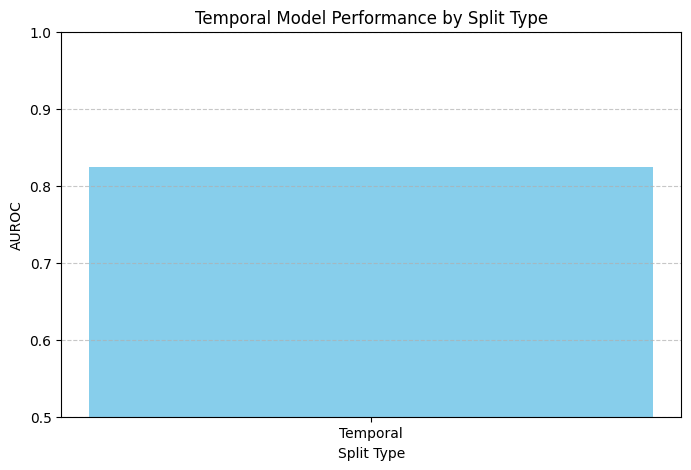

Temporal split results saved


In [ ]:
# Temporal split evaluation and visualization (Model pipeline for temporal split)

from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import os
from IPython.display import display, Markdown

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------------------------------------------
# Temporal Split
# --------------------------------------------
split_point = "2014J"

train = df[df["presentation"] < split_point].copy()
test  = df[df["presentation"] >= split_point].copy()

# --------------------------------------------
# Features / Target
# --------------------------------------------
X_train = train.drop(columns=["target", "id_student"], errors="ignore")
y_train = train["target"]

X_test = test.drop(columns=["target", "id_student"], errors="ignore")
y_test = test["target"]

# Encode
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# --------------------------------------------
# Model
# --------------------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

prob = model.predict_proba(X_test)[:,1]

auroc = roc_auc_score(y_test, prob)

# --------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------
display(Markdown("## Temporal Split Results"))

results_temp = pd.DataFrame({
    "Split": ["Temporal"],
    "AUROC": [auroc],
    "Train Size": [X_train.shape[0]],
    "Test Size": [X_test.shape[0]]
})

display(results_temp)

# --------------------------------------------
# SAVE CSV
# --------------------------------------------
results_temp.to_csv(f"{OUTPUT_DIR}/temporal_results.csv", index=False)
train.to_csv(f"{OUTPUT_DIR}/train_temporal.csv", index=False)
test.to_csv(f"{OUTPUT_DIR}/test_temporal.csv", index=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(results_temp['Split'], results_temp['AUROC'], color='skyblue')
plt.xlabel('Split Type')
plt.ylabel('AUROC')
plt.title('Temporal Model Performance by Split Type')
plt.xticks(results_temp['Split'])
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Temporal split results saved")

### Shuffle Leakage Test (only if I need to adjust )

## Leakage Validation: Original vs Shuffled

,AUROC,AUPRC,F1,Precision,Recall,Balanced_Accuracy
Original,0.840229,0.846444,0.733813,0.789540,0.685434,0.760635
Shuffled,0.509784,0.484290,0.407747,0.477794,0.355612,0.503198


<Figure size 600x400 with 0 Axes>

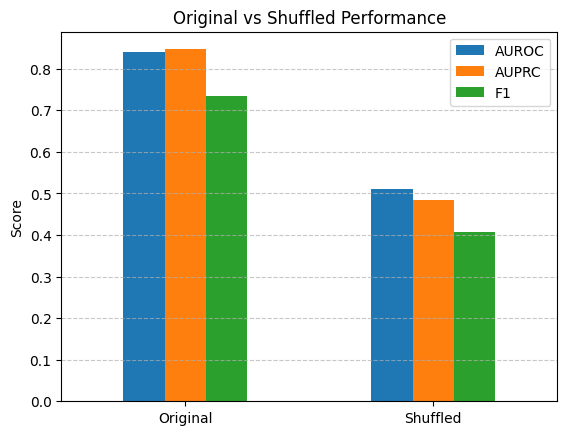

In [ ]:
# If high AUROC after shuffle then leakeage
# If AUROC is around 0.5 after shuffle then no leakeage

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:,1]
    pred = model.predict(X_test)

    return {
        "AUROC": roc_auc_score(y_test, prob),
        "AUPRC": average_precision_score(y_test, prob),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, pred)
    }

# Shuffle test set to check for leakage

def shuffle_test(model, X_train, y_train, X_test, y_test):

    y_shuf = y_train.sample(frac=1.0, random_state=42)

    return evaluate_model(model, X_train, y_shuf, X_test, y_test)

# Full pipeline for temporal split evaluation with leakage check

import os
from IPython.display import display, Markdown

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------
# Prepare data
# ------------------------------
X = df.drop(
    columns=['target','id_student','code_module','code_presentation','final_result'],
    errors='ignore'
)
y = df['target']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

model = RandomForestClassifier(n_estimators=200, random_state=42)

# ------------------------------
# Evaluate ORIGINAL
# ------------------------------
original_metrics = evaluate_model(model, X_train, y_train, X_test, y_test)

# ------------------------------
# Evaluate SHUFFLED
# ------------------------------
shuffled_metrics = shuffle_test(model, X_train, y_train, X_test, y_test)

# ------------------------------
# Combine results
# ------------------------------
results_df = pd.DataFrame([original_metrics, shuffled_metrics])
results_df.index = ["Original", "Shuffled"]

# ------------------------------
# DISPLAY TABLE
# ------------------------------
display(Markdown("## Leakage Validation: Original vs Shuffled"))

display(results_df)

# Visualization
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

results_df[["AUROC","AUPRC","F1"]].plot(kind="bar")
plt.title("Original vs Shuffled Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Save results
results_df.to_csv(f"{OUTPUT_DIR}/leakage_validation_results.csv", index=True)   

Leakeage detection visuallization

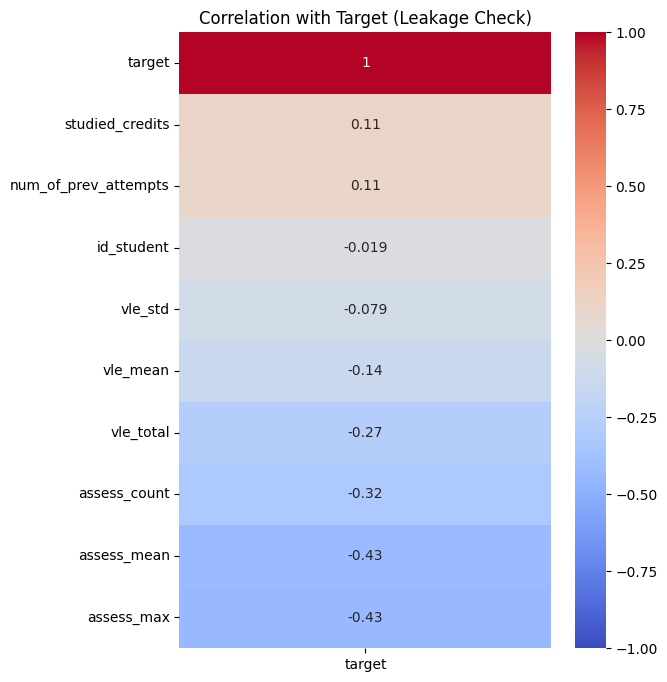

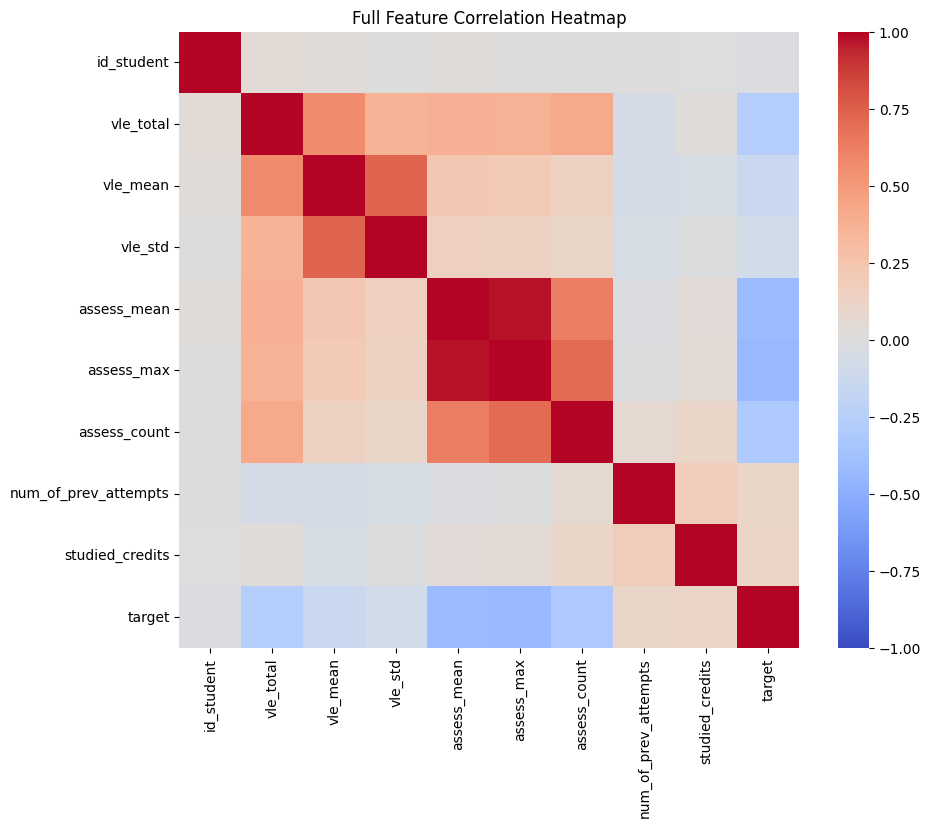

In [ ]:
#Leak detection visualization

import seaborn as sns
import matplotlib.pyplot as plt

numeric = df.select_dtypes('number')

corr_target = numeric.corr()['target'].sort_values(ascending=False)

plt.figure(figsize=(6,8))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation with Target (Leakage Check)")
plt.show()

# HEatmap of feature correlations to identify clusters of highly correlated features (potential leakage)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Full Feature Correlation Heatmap")
plt.show()

# Save the results of the correlation analysis to CSV for further inspection
corr.to_csv(f"{OUTPUT_DIR}/feature_correlations.csv")


Top feature importances

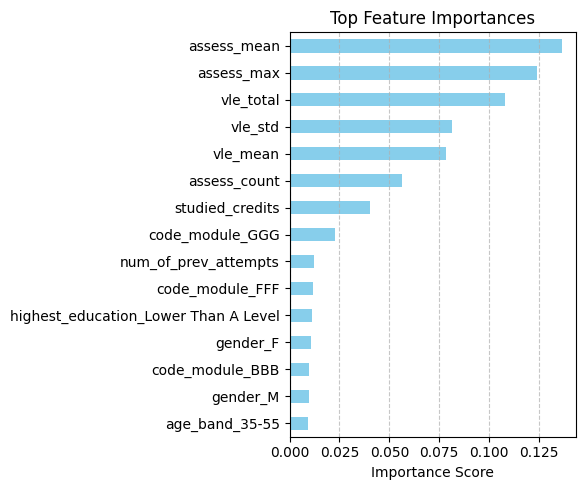

In [ ]:
X=df.drop(columns=['target','id_student'])
y=df['target']
X=pd.get_dummies(X)
model=RandomForestClassifier()
model.fit(X,y)
imp=pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,5))

imp.head(15).sort_values().plot(kind='barh', color='skyblue')

plt.title("Top Feature Importances")
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 8. Train/Test Split

## Random Split Results

,Week,AUROC,Split
0,2,0.742386,Random
1,4,0.798896,Random
2,6,0.822922,Random
3,8,0.853257,Random


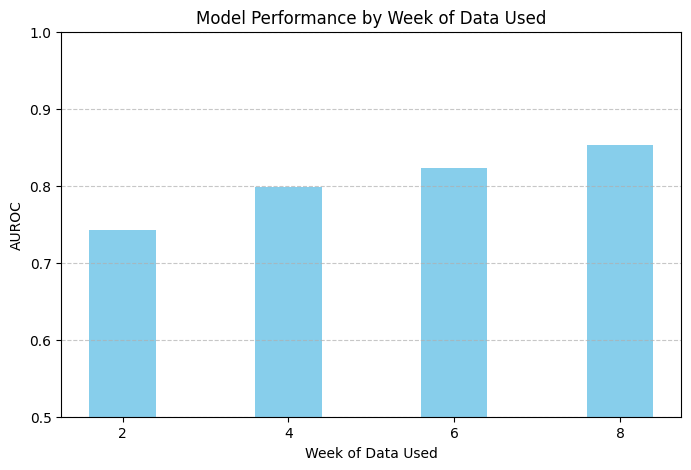

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

results_random = []

for week, data in datasets.items():

    X = data.drop(columns=["target", "id_student"], errors="ignore")
    y = data["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42   # For reproducibility
    )

    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)

    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]

    auroc = roc_auc_score(y_test, prob)

    results_random.append({
        "Week": week,
        "AUROC": auroc,
        "Split": "Random"
    })

results_random_df = pd.DataFrame(results_random)

# --------------------------------------------
# DISPLAY
# --------------------------------------------
display(Markdown("## Random Split Results"))
display(results_random_df)

# --------------------------------------------
# SAVE CSV
# --------------------------------------------
results_random_df.to_csv(f"{OUTPUT_DIR}/random_results.csv", index=False)



import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(results_random_df['Week'], results_random_df['AUROC'], color='skyblue')
plt.xlabel('Week of Data Used')
plt.ylabel('AUROC')
plt.title('Model Performance by Week of Data Used')
plt.xticks(results_random_df['Week'])
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Temporal Split Results

,Split,AUROC,Train Size,Test Size
0,Temporal,0.824121,18983,10100


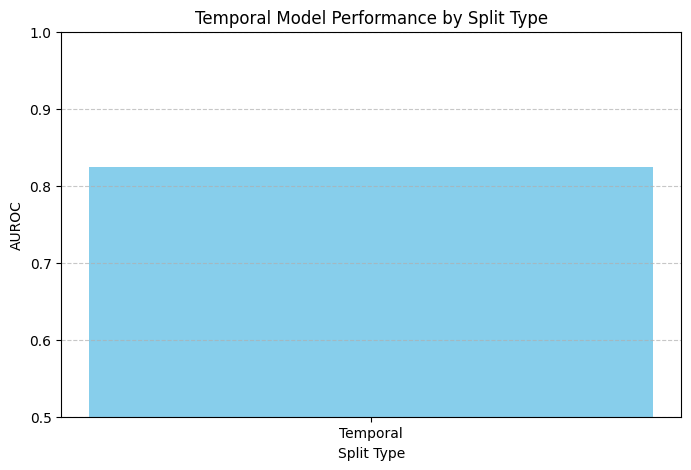

Temporal split results saved


=== CLASS DISTRIBUTION (%) ===
         Original      Train       Test
target                                 
0       52.676822  52.677727  52.673199
1       47.323178  47.322273  47.326801

=== DISTRIBUTION DIFFERENCES (%) ===
         Original      Train       Test  Train-Original  Test-Original
target                                                                
0       52.676822  52.677727  52.673199        0.000906      -0.003622
1       47.323178  47.322273  47.326801       -0.000906       0.003622


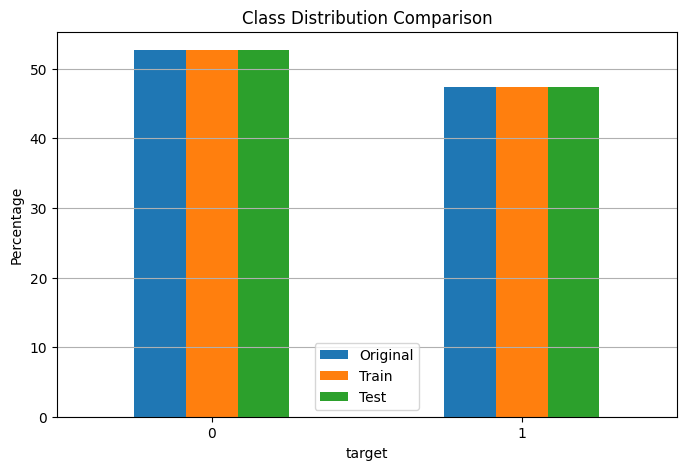

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def compare_distributions(df):

    # Split
    X = df.drop(columns=['target', 'id_student'])
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Combined into dataframe for comparison
    dist_df = pd.DataFrame({
        'Original': y.value_counts(normalize=True),
        'Train': y_train.value_counts(normalize=True),
        'Test': y_test.value_counts(normalize=True)
    }) * 100

    print("=== CLASS DISTRIBUTION (%) ===")
    print(dist_df)

    # Difference table
    diff_df = dist_df.copy()
    diff_df['Train-Original'] = diff_df['Train'] - diff_df['Original']
    diff_df['Test-Original'] = diff_df['Test'] - diff_df['Original']

    print("\n=== DISTRIBUTION DIFFERENCES (%) ===")
    print(diff_df)

    # Visualization
    dist_df.plot(kind='bar', figsize=(8,5))
    plt.title("Class Distribution Comparison")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()

    return dist_df, diff_df
dist_df, diff_df = compare_distributions(datasets[8])

## 9. Underfitting Diagnostics

# UNDERFITTING DIAGNOSTICS — Week 2

## Class Distribution

,Class,Percentage
0,0,0.533706
1,1,0.466294


## Feature Sparsity (Top 10)

,Sparsity
age_band_55<=,0.992913
highest_education_No Formal quals,0.989993
highest_education_Post Graduate Qualification,0.989495
code_module_AAA,0.974004
imd_band_Unknown,0.963071
region_Ireland,0.962715
region_North Region,0.943164
region_Yorkshire Region,0.939034
region_South East Region,0.934725
region_Wales,0.933621


...

,Constant Feature Count
0,0


## VLE Activity Signal

,Mean Activity
vle_mean,2.967193
vle_std,4.033170
vle_total,220.622556


## Summary

,At_Risk_%,Low_Risk_%,Avg_Sparsity,Avg_Variance,Samples,Features,Constant_Features,Avg_VLE_Signal
0,0.466294,0.533706,0.772918,1571.776499,28081,55,0,75.874306


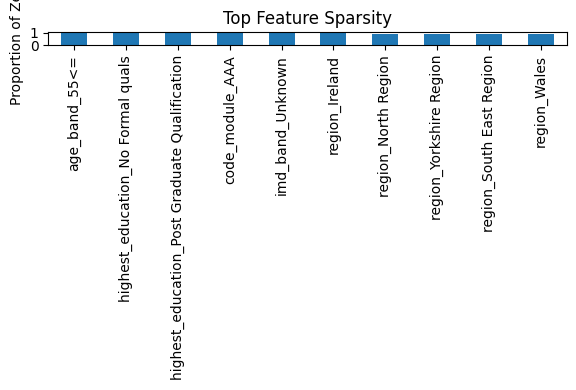

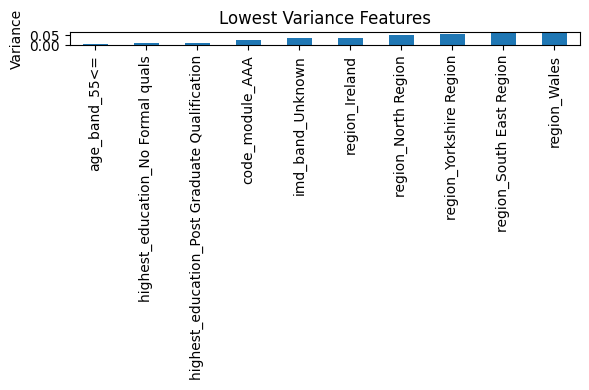

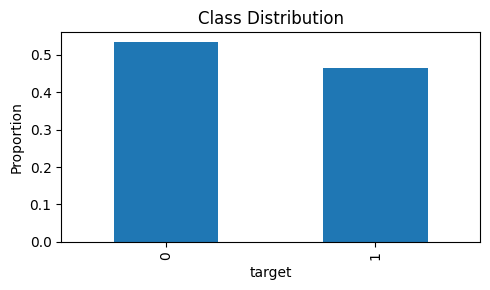

# UNDERFITTING DIAGNOSTICS — Week 4

## Class Distribution

,Class,Percentage
0,0,0.528689
1,1,0.471311


## Feature Sparsity (Top 10)

,Sparsity
age_band_55<=,0.992915
highest_education_No Formal quals,0.990067
highest_education_Post Graduate Qualification,0.989580
code_module_AAA,0.974507
imd_band_Unknown,0.963670
region_Ireland,0.961830
region_North Region,0.943630
region_Yorkshire Region,0.939219
region_South East Region,0.935121
region_Wales,0.933176


...

,Constant Feature Count
0,0


## VLE Activity Signal

,Mean Activity
vle_mean,3.156625
vle_std,4.745675
vle_total,350.574118


## Summary

,At_Risk_%,Low_Risk_%,Avg_Sparsity,Avg_Variance,Samples,Features,Constant_Features,Avg_VLE_Signal
0,0.471311,0.528689,0.740865,3356.431219,28792,55,0,119.492139


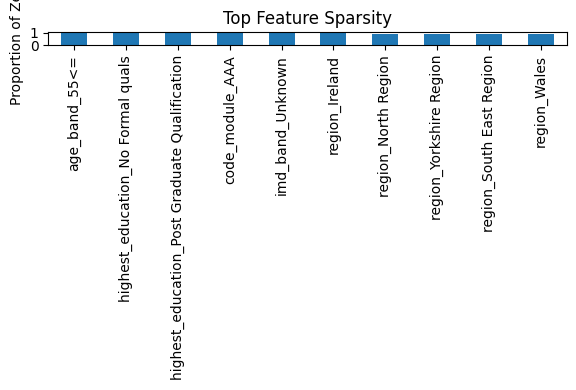

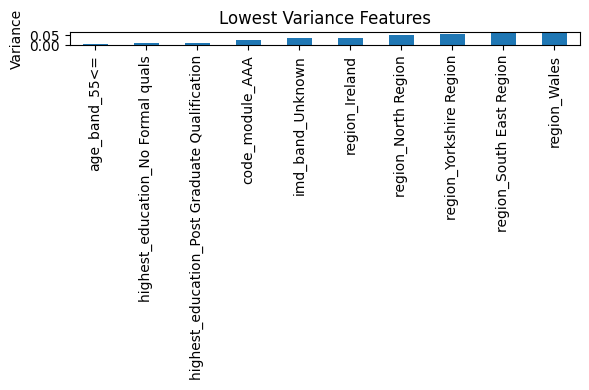

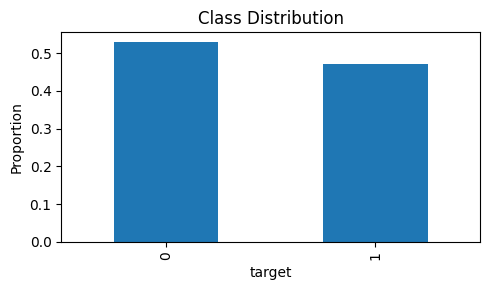

# UNDERFITTING DIAGNOSTICS — Week 6

## Class Distribution

,Class,Percentage
0,0,0.527146
1,1,0.472854


## Feature Sparsity (Top 10)

,Sparsity
age_band_55<=,0.992959
highest_education_No Formal quals,0.990060
highest_education_Post Graduate Qualification,0.989611
code_module_AAA,0.974666
imd_band_Unknown,0.963794
region_Ireland,0.961792
region_North Region,0.943844
region_Yorkshire Region,0.939288
region_South East Region,0.935112
region_Wales,0.933214


...

,Constant Feature Count
0,0


## VLE Activity Signal

,Mean Activity
vle_mean,3.139440
vle_std,4.719218
vle_total,441.944500


## Summary

,At_Risk_%,Low_Risk_%,Avg_Sparsity,Avg_Variance,Samples,Features,Constant_Features,Avg_VLE_Signal
0,0.472854,0.527146,0.735884,5278.031769,28973,55,0,149.934386


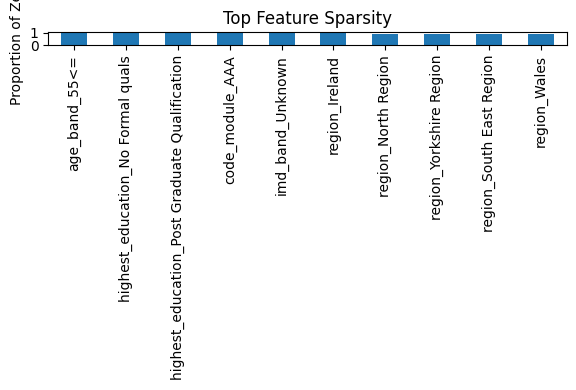

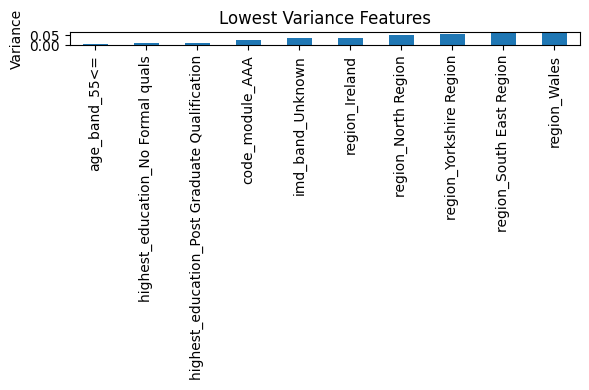

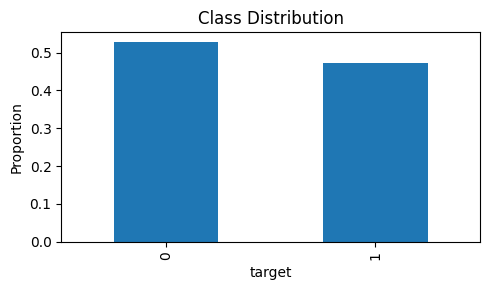

# UNDERFITTING DIAGNOSTICS — Week 8

## Class Distribution

,Class,Percentage
0,0,0.526768
1,1,0.473232


## Feature Sparsity (Top 10)

,Sparsity
age_band_55<=,0.992951
highest_education_No Formal quals,0.990029
highest_education_Post Graduate Qualification,0.989616
code_module_AAA,0.974728
imd_band_Unknown,0.963896
region_Ireland,0.961833
region_North Region,0.943885
region_Yorkshire Region,0.939243
region_South East Region,0.935014
region_Wales,0.933226


...

,Constant Feature Count
0,0


## VLE Activity Signal

,Mean Activity
vle_mean,3.143475
vle_std,4.782262
vle_total,529.682323


## Summary

,At_Risk_%,Low_Risk_%,Avg_Sparsity,Avg_Variance,Samples,Features,Constant_Features,Avg_VLE_Signal
0,0.473232,0.526768,0.734382,7661.574802,29083,55,0,179.202687


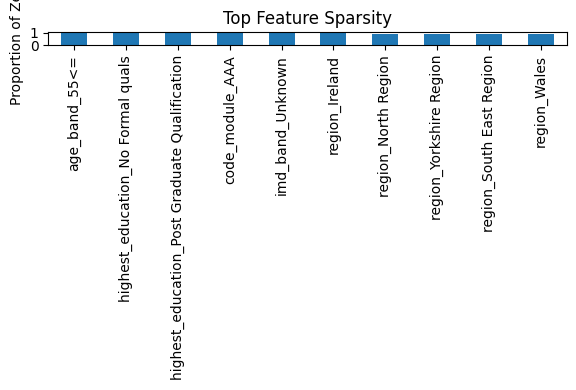

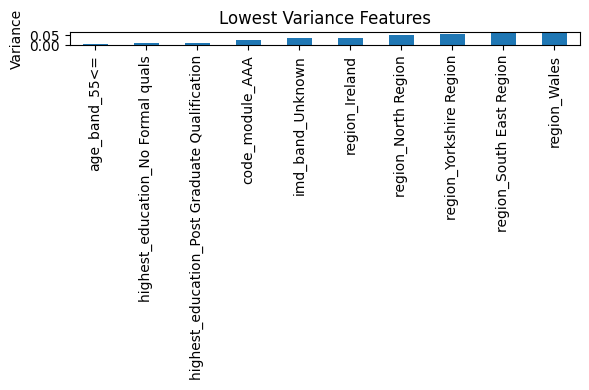

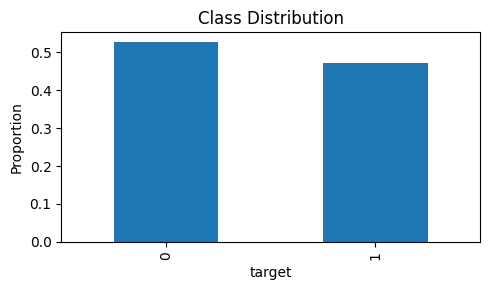

,At_Risk_%,Low_Risk_%,Avg_Sparsity,Avg_Variance,Samples,Features,Constant_Features,Avg_VLE_Signal,Week
0,0.466294,0.533706,0.772918,1571.776499,28081,55,0,75.874306,2
1,0.471311,0.528689,0.740865,3356.431219,28792,55,0,119.492139,4
2,0.472854,0.527146,0.735884,5278.031769,28973,55,0,149.934386,6
3,0.473232,0.526768,0.734382,7661.574802,29083,55,0,179.202687,8


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# MAIN FUNCTION
# =========================================================
def diagnose_underfitting_oulad(df, save_prefix="underfitting"):

    # -------------------------------
    # HANDLE MULTIPLE WEEKS
    # -------------------------------
    if isinstance(df, dict):
        all_summary = []

        for w, df_w in df.items():
            display(Markdown(f"# UNDERFITTING DIAGNOSTICS — Week {w}"))

            summary_df = diagnose_underfitting_oulad(df_w, save_prefix=f"week_{w}")
            summary_df["Week"] = w
            all_summary.append(summary_df)

        final_summary = pd.concat(all_summary, ignore_index=True)

        final_summary.to_csv(f"{OUTPUT_DIR}/underfitting_summary_all_weeks.csv", index=False)

        return final_summary

    # =========================================================
    # SINGLE DATASET
    # =========================================================
    summary = {}

    # -------------------------------
    # 1. CLASS BALANCE
    # -------------------------------
    class_dist = df['target'].value_counts(normalize=True)

    summary["At_Risk_%"] = class_dist.get(1, 0)
    summary["Low_Risk_%"] = class_dist.get(0, 0)

    class_df = class_dist.reset_index()
    class_df.columns = ["Class", "Percentage"]

    display(Markdown("## Class Distribution"))
    display(class_df)

    # -------------------------------
    # 2. FEATURE MATRIX
    # -------------------------------
    X = df.drop(columns=['target', 'id_student'], errors='ignore')
    X = pd.get_dummies(X)

    # -------------------------------
    # 3. SPARSITY
    # -------------------------------
    sparsity = (X == 0).mean().sort_values(ascending=False)

    summary["Avg_Sparsity"] = sparsity.mean()

    display(Markdown("## Feature Sparsity (Top 10)"))
    display(sparsity.head(10).to_frame("Sparsity"))

    # -------------------------------
    # 4. VARIANCE
    # -------------------------------
    variance = X.var().sort_values()

    summary["Avg_Variance"] = variance.mean()

    display(Markdown("## Lowest Variance Features"))
    display(variance.head(10).to_frame("Variance"))

    # -------------------------------
    # 5. SHAPE
    # -------------------------------
    summary["Samples"] = X.shape[0]
    summary["Features"] = X.shape[1]

    shape_df = pd.DataFrame({
        "Metric": ["Samples", "Features"],
        "Value": [X.shape[0], X.shape[1]]
    })

    display(Markdown("## Dataset Shape"))
    display(shape_df)

    # -------------------------------
    # 6. CONSTANT FEATURES
    # -------------------------------
    const_cols = [c for c in X.columns if X[c].nunique() <= 1]

    summary["Constant_Features"] = len(const_cols)

    display(Markdown("## Constant Features"))
    display(pd.DataFrame({"Constant Feature Count": [len(const_cols)]}))

    # -------------------------------
    # 7. OULAD-SPECIFIC SIGNAL
    # -------------------------------
    vle_cols = [c for c in X.columns if "vle_" in c]

    if vle_cols:
        vle_signal = X[vle_cols].mean().sort_values()

        summary["Avg_VLE_Signal"] = vle_signal.mean()

        display(Markdown("## VLE Activity Signal"))
        display(vle_signal.head(10).to_frame("Mean Activity"))

    # -------------------------------
    # 8. COLLECT SUMMARY
    # -------------------------------
    summary_df = pd.DataFrame([summary])

    display(Markdown("## Summary"))
    display(summary_df)

    # -------------------------------
    # 9. SAVE RESULTS
    # -------------------------------
    summary_df.to_csv(f"{OUTPUT_DIR}/{save_prefix}_summary.csv", index=False)
    sparsity.to_csv(f"{OUTPUT_DIR}/{save_prefix}_sparsity.csv")
    variance.to_csv(f"{OUTPUT_DIR}/{save_prefix}_variance.csv")

    # -------------------------------
    # 10. VISUALIZATIONS)
    # -------------------------------

    # Feature Sparsity
    plt.figure(figsize=(6,4))
    sparsity.head(10).plot(kind="bar")
    plt.title("Top Feature Sparsity")
    plt.ylabel("Proportion of Zeros")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_prefix}_sparsity_plot.png")
    plt.show()

    # Variance
    plt.figure(figsize=(6,4))
    variance.head(10).plot(kind="bar")
    plt.title("Lowest Variance Features")
    plt.ylabel("Variance")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_prefix}_variance_plot.png")
    plt.show()

    # Class Distribution
    plt.figure(figsize=(5,3))
    class_dist.plot(kind="bar")
    plt.title("Class Distribution")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_prefix}_class_distribution.png")
    plt.show()

    return summary_df

diagnose_underfitting_oulad(datasets)

## 10. Scikit-learn Pipeline

[LightGBM] [Info] Number of positive: 78, number of negative: 222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 295
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260000 -> initscore=-1.045969
[LightGBM] [Info] Start training from score -1.045969
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

## Mean AUROC per Week

,Week,Model,AUROC
0,2,LightGBM,0.610517
1,2,RF,0.638260
2,2,XGB,0.608007
3,4,LightGBM,0.696971
4,4,RF,0.720480
5,4,XGB,0.694194
6,6,LightGBM,0.734842
7,6,RF,0.754201
8,6,XGB,0.729991
9,8,LightGBM,0.773440


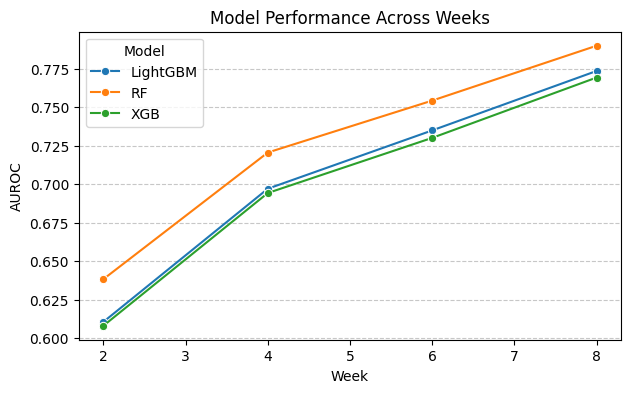

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler

def build_pipeline(model):

    num_cols = [
        'vle_total','vle_mean','vle_std',
        'assess_mean','assess_max','assess_count'
    ]

    cat_cols = ['code_module','code_presentation']

    pre = ColumnTransformer([

        # NUMERIC WITH SCALING
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value=0)),
            ('scaler', StandardScaler())
        ]), num_cols),

        # CATEGORICAL
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)

    ])

    return Pipeline([
        ('pre', pre),
        ('model', model)
    ])

# Evaluation function for explicit metrics
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

def evaluate_model(pipe, X_test, y_test):

    prob = pipe.predict_proba(X_test)[:,1]
    pred = pipe.predict(X_test)

    return {
        "AUROC": roc_auc_score(y_test, prob),
        "AUPRC": average_precision_score(y_test, prob),
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "balanced_accuracy_score": balanced_accuracy_score(y_test, pred)
    }

# Course evaluation 
def course_performance(df, model, model_name, week):

    rows = []

    for (m, p), g in df.groupby(['code_module','code_presentation']):

        if len(g) < 10 or g['target'].nunique() < 2:
            continue

        X = g.drop(columns=['target','id_student','final_result'], errors='ignore')
        y = g['target']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            stratify=y,
            random_state=42
        )

        pipe = build_pipeline(model)
        pipe.fit(X_train, y_train)

        perf = evaluate_model(pipe, X_test, y_test)

        row = {
            "Week": week,
            "Model": model_name,
            "Course": f"{m}_{p}"
        }
        row.update(perf)

      # removed stray closing parenthesis
        rows.append(row)
    return pd.DataFrame(rows)

# Accross weeks evaluation
models = {
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGB": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss"),
    "LightGBM" : LGBMClassifier(n_estimators=200, random_state=42)
}

# Adjust LightGBM parameters for better performance and to avoid overfitting on small courses
LGBMClassifier(
    n_estimators=200,
    num_leaves=15,           # smaller tree
    min_child_samples=20,    # avoid small splits
    min_gain_to_split=0.0,   # allow splits
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    force_col_wise=True,     # remove warning overhead
    random_state=42
)

# Remove scaling for tree models as they are not sensitive to feature scaling

def build_pipeline(model):

    num_cols = [
        'vle_total','vle_mean','vle_std',
        'assess_mean','assess_max','assess_count'
    ]

    cat_cols = ['code_module','code_presentation']

    pre = ColumnTransformer([

        # ✅ NO scaling for trees
        ('num', SimpleImputer(strategy='constant', fill_value=0), num_cols),

        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)

    ])

    return Pipeline([
        ('pre', pre),
        ('model', model)
    ])


all_results = []

for week, data in datasets.items():

    for name, model in models.items():

        df_res = course_performance(data, model, name, week)

        if not df_res.empty:
            all_results.append(df_res)

results_df = pd.concat(all_results, ignore_index=True)



# Summary table
summary_df = (
    results_df
    .groupby(["Week","Model"])["AUROC"]
    .mean()
    .reset_index()
)

display(Markdown("## Mean AUROC per Week"))
display(summary_df)

# Visualization of AUROC trends across weeks

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.lineplot(
    data=summary_df,
    x="Week",
    y="AUROC",
    hue="Model",
    marker="o"
)

plt.title("Model Performance Across Weeks")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Save results to CSV

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_df.to_csv(f"{OUTPUT_DIR}/course_level_pipeline_results.csv", index=False)
summary_df.to_csv(f"{OUTPUT_DIR}/summary_pipeline_results.csv", index=False)



### Temporal split on full dataset
Evaluaiton per course

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 98, number of negative: 277
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 375, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.261333 -> initscore=-1.039050
[LightGBM] [Info] Start training from score -1.039050
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## Temporal Course Evaluation

,Week,Model,Course,AUROC,AUPRC,Accuracy,F1,recall,precision,balanced_accuracy_score
0,2,RF,AAA_2014J,0.597497,0.380983,0.704225,0.265734,0.186275,0.463415,0.549659
1,2,RF,BBB_2014J,0.675357,0.558805,0.649094,0.541935,0.522822,0.562500,0.627531
2,2,RF,CCC_2014J,0.706924,0.725924,0.655745,0.704659,0.746330,0.667396,0.645620
3,2,RF,DDD_2014J,0.733660,0.732429,0.659218,0.702439,0.781665,0.637795,0.655538
4,2,RF,EEE_2014J,0.715603,0.604565,0.699812,0.530792,0.461735,0.624138,0.650007
5,2,RF,FFF_2014J,0.741054,0.703633,0.680115,0.663976,0.677652,0.650841,0.679960
6,2,RF,GGG_2014J,0.616184,0.436362,0.642741,0.242215,0.165877,0.448718,0.529456
7,2,XGB,AAA_2014J,0.603774,0.377572,0.661972,0.361702,0.333333,0.395349,0.563900
8,2,XGB,BBB_2014J,0.644010,0.528100,0.605711,0.542092,0.587828,0.502959,0.602657
9,2,XGB,CCC_2014J,0.669416,0.699489,0.623429,0.675184,0.711256,0.642594,0.613612


## Temporal Performance Summary

,Week,Model,AUROC
0,2,LightGBM,0.666230
1,2,RF,0.683754
2,2,XGB,0.662090
3,4,LightGBM,0.722554
4,4,RF,0.740988
5,4,XGB,0.712827
6,6,LightGBM,0.747829
7,6,RF,0.761219
8,6,XGB,0.735377
9,8,LightGBM,0.780669


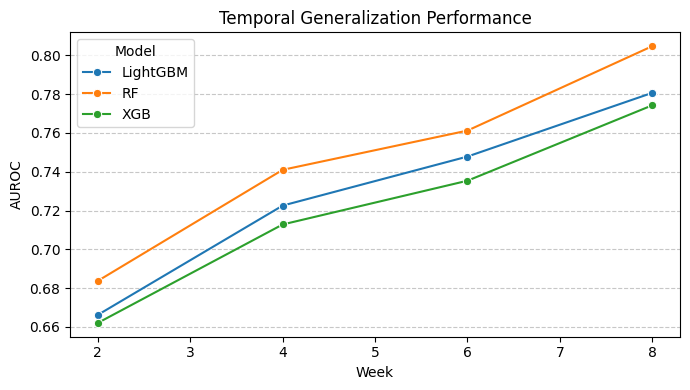

Temporal results saved to: output_results


In [ ]:

from IPython.display import display, Markdown
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# TEMPORAL COURSE EVALUATION FUNCTION
# =====================================================
def evaluate_course_temporal(df, model, model_name, week):

    results = []
    split_point = "2014J"

    # -----------------------------
    # GLOBAL temporal split
    # -----------------------------
    train = df[df['code_presentation'] < split_point].copy()
    test  = df[df['code_presentation'] >= split_point].copy()

    # -----------------------------
    # ✅ Evaluate per course (test set)
    # -----------------------------
    for (module, presentation), group_test in test.groupby(['code_module','code_presentation']):

        group_train = train[train['code_module'] == module]

        # Skip invalid cases
        if group_train.empty or group_test['target'].nunique() < 2:
            continue

        # -----------------------------
        # ✅ Features
        # -----------------------------
        X_train = group_train.drop(
            columns=['target','id_student','code_module','code_presentation'],
            errors='ignore'
        )
        y_train = group_train['target']

        X_test = group_test.drop(
            columns=['target','id_student','code_module','code_presentation'],
            errors='ignore'
        )
        y_test = group_test['target']

        # -----------------------------
        # ✅ Encoding
        # -----------------------------
        X_train = pd.get_dummies(X_train)
        X_test = pd.get_dummies(X_test)

        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        # -----------------------------
        # Train and evaluate
        # -----------------------------
        model.fit(X_train, y_train)
        metrics = evaluate_model(model, X_test, y_test)

        results.append({
            "Week": week,
            "Model": model_name,
            "Course": f"{module}_{presentation}",
            **metrics
        })

    return pd.DataFrame(results)


# =====================================================
# RUN TEMPORAL EVALUATION ACROSS WEEKS
# =====================================================
all_results = []

for week, data in datasets.items():
    # sanitize feature sources to avoid invalid dummy column names (e.g., "55<=")
    data_clean = data.copy()

    # ensure column names are valid strings
    data_clean.columns = (
        data_clean.columns.astype(str)
        .str.replace(r"[\[\]<>]", "_", regex=True)
    )

    # sanitize categorical values before get_dummies creates feature names
    cat_cols = data_clean.select_dtypes(include=["object", "category"]).columns
    for col in cat_cols:
        data_clean[col] = (
            data_clean[col]
            .astype(str)
            .str.replace(r"[\[\]<>]", "_", regex=True)
        )

    for model_name, model in models.items():
        df_res = evaluate_course_temporal(data_clean, model, model_name, week)
        if not df_res.empty:
            all_results.append(df_res)

# Handle empty case safely
results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# =====================================================
# DISPLAY RESULTS
# =====================================================
display(Markdown("## Temporal Course Evaluation"))

if not results_df.empty:
    display(results_df.head(15))
else:
    display(Markdown("No temporal results were generated."))


# =====================================================
# SUMMARY TABLE
# =====================================================
if not results_df.empty:

    summary_df = (
        results_df
        .groupby(["Week", "Model"])["AUROC"]
        .mean()
        .reset_index()
    )

    display(Markdown("## Temporal Performance Summary"))
    display(summary_df)

    # =====================================================
    # VISUALIZATION
    # =====================================================
    plt.figure(figsize=(7, 4))

    sns.lineplot(
        data=summary_df,
        x="Week",
        y="AUROC",
        hue="Model",
        marker="o"
    )

    plt.title("Temporal Generalization Performance")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # SAVE RESULTS
    # =====================================================
    OUTPUT_DIR = "output_results"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results_df.to_csv(f"{OUTPUT_DIR}/temporal_course_results.csv", index=False)
    summary_df.to_csv(f"{OUTPUT_DIR}/temporal_summary.csv", index=False)

    print(f"Temporal results saved to: {OUTPUT_DIR}")

else:
    print("No results to save.")


## Baseline modeling (Explicit + Reproducible)

## Train/Test Split Summary

,Dataset,Rows,Columns,Class Balance (% At-Risk)
0,Train,23266,59,0.473
1,Test,5817,59,0.473


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11010, number of negative: 12256
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1258
[LightGBM] [Info] Number of data points in the train set: 23266, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473223 -> initscore=-0.107212
[LightGBM] [Info] Start training from score -0.107212


## Model Evaluation Performance

,AUROC,AUPRC,F1,Precision,Recall
Model,,,,,
Logistic Regression,0.836960,0.847704,0.734104,0.781699,0.691972
Random Forest,0.853604,0.863533,0.745337,0.811111,0.689430
Gradient Boosting,0.861358,0.870138,0.751673,0.820094,0.693789
XGBoost,0.840055,0.852327,0.741972,0.782977,0.705049
LightGBM,0.859671,0.868904,0.753737,0.821965,0.695968


<Figure size 800x500 with 0 Axes>

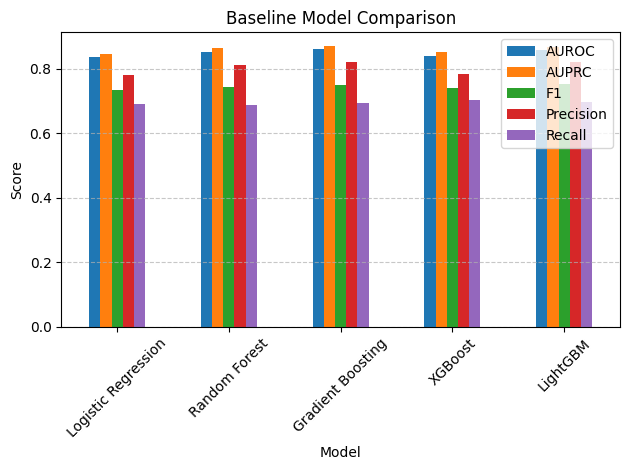

Results saved to output_results


In [ ]:
# Baseline modeling (Explicit + Reproductible)

import os
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Feature matrix
# Remove identifiers and ensure reproducibility
X_clean = X.copy()

# One-hot encode categorical variables
X_clean = pd.get_dummies(X_clean)

# Ensure alignment (important if re-running)
X_clean = X_clean.fillna(0)

# Reproducibility split: Save the cleaned feature matrix

# Split definition:
# - test_size = 0.2 (20%)
# - stratified = True (class balance preserved)
# - seed = 42 (reproducible)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Display split summary

split_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]],
    "Class Balance (% At-Risk)": [
        y_train.mean().round(3),
        y_test.mean().round(3)
    ]
})

display(Markdown("## Train/Test Split Summary"))
display(split_summary)

# Models:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(n_estimators=200, random_state=42)
}

# Evaluation function:

def evaluate_model(model, X_test, y_test):

    prob = model.predict_proba(X_test)[:,1]
    pred = model.predict(X_test)

    return {
        "AUROC": roc_auc_score(y_test, prob),
        "AUPRC": average_precision_score(y_test, prob),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0)
    }

# Train and collect results

results = []

for name, model in models.items():

    X_train_model = X_train.copy()
    X_test_model = X_test.copy()

    # XGBoost-compatible feature names (strings, no [, ], <, >)
    safe_cols = (
        X_train_model.columns.astype(str)
        .str.replace(r"[\[\]<>]", "_", regex=True)
    )
    X_train_model.columns = safe_cols
    X_test_model.columns = safe_cols

    model.fit(X_train_model, y_train)
    X_test = X_test_model

    metrics = evaluate_model(model, X_test, y_test)

    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")

# Display results
display(Markdown("## Model Evaluation Performance"))
display(results_df)


# Visualization

plt.figure(figsize=(8,5))

plot_df = results_df.copy()

# Support either naming convention
if "balanced_accuracy_score" in plot_df.columns and "Balanced Accuracy" not in plot_df.columns:
    plot_df["Balanced Accuracy"] = plot_df["balanced_accuracy_score"]

plot_cols = ["AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced Accuracy"]
plot_cols = [c for c in plot_cols if c in plot_df.columns]

plot_df[plot_cols].plot(kind="bar")

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Save results

results_df.to_csv(f"{OUTPUT_DIR}/baseline_model_results.csv")
split_summary.to_csv(f"{OUTPUT_DIR}/baseline_split_summary.csv", index=False)

print(f"Results saved to {OUTPUT_DIR}")



# Week 2 Modeling

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10475, number of negative: 11989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1106
[LightGBM] [Info] Number of data points in the train set: 22464, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.466302 -> initscore=-0.134998
[LightGBM] [Info] Start training from score -0.134998


,Week,AUROC,AUPRC,F1,Precision,Recall,Balanced Accuracy
Model,,,,,,,
LogReg,2,0.738515,0.709914,0.647586,0.660707,0.634975,0.675059
RF,2,0.742386,0.713831,0.646953,0.678541,0.618175,0.681169
GB,2,0.758001,0.735726,0.654743,0.691133,0.621993,0.689582
XGBoost,2,0.731530,0.703474,0.647415,0.662011,0.633448,0.675463
LightGBM,2,0.747674,0.722257,0.651255,0.674857,0.629248,0.682202


# Week 4 Modeling

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10856, number of negative: 12177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1180
[LightGBM] [Info] Number of data points in the train set: 23033, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.471324 -> initscore=-0.114831
[LightGBM] [Info] Start training from score -0.114831


...

,Week,AUROC,AUPRC,F1,Precision,Recall,Balanced Accuracy
Model,,,,,,,
LogReg,8,0.836969,0.847733,0.733860,0.781609,0.691609,0.758990
RF,8,0.853257,0.862708,0.745923,0.812500,0.689430,0.773240
GB,8,0.861356,0.870136,0.751673,0.820094,0.693789,0.778520
XGBoost,8,0.840055,0.852327,0.741972,0.782977,0.705049,0.764731
LightGBM,8,0.859671,0.868904,0.753737,0.821965,0.695968,0.780262


# Combined Results

,Week,Model,AUROC,AUPRC,F1,Precision,Recall,Balanced Accuracy
0,2,LogReg,0.738515,0.709914,0.647586,0.660707,0.634975,0.675059
1,2,RF,0.742386,0.713831,0.646953,0.678541,0.618175,0.681169
2,2,GB,0.758001,0.735726,0.654743,0.691133,0.621993,0.689582
3,2,XGBoost,0.731530,0.703474,0.647415,0.662011,0.633448,0.675463
4,2,LightGBM,0.747674,0.722257,0.651255,0.674857,0.629248,0.682202


## Mean AUROC by Week

,Week,Model,AUROC
0,2,GB,0.758001
1,2,LightGBM,0.747674
2,2,LogReg,0.738515
3,2,RF,0.742386
4,2,XGBoost,0.731530
5,4,GB,0.810644
6,4,LightGBM,0.804101
7,4,LogReg,0.791380
8,4,RF,0.798896
9,4,XGBoost,0.786860


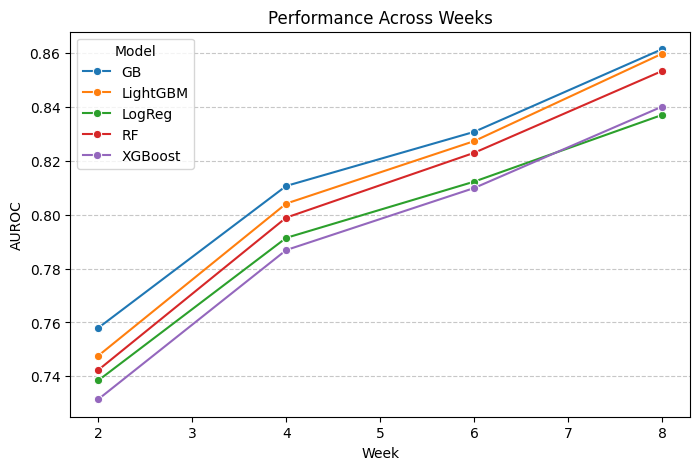

All results saved to output_results


In [ ]:
# Modeling by week 2, 4, 6, and 8 with explicit reproducibility and evaluation metrics
import os
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ======================================================
# SETUP
# ======================================================
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

weeks = [2,4,6,8]

# ======================================================
# MODELS
# ======================================================
models = {
    "LogReg": LogisticRegression(max_iter=10000, random_state=SEED),
    "RF": RandomForestClassifier(n_estimators=200, random_state=SEED),
    "GB": GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=SEED, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(n_estimators=200, random_state=SEED)
}

all_results = []
all_predictions = []

# ======================================================
# LOOP OVER WEEKS
# ======================================================
for week in weeks:

    if week not in datasets:
        continue

    display(Markdown(f"# Week {week} Modeling"))

    data = datasets[week]

    X = data.drop(columns=['target','id_student'], errors='ignore')
    y = data['target']

    # ------------------------------
    # SPLIT
    # ------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=SEED
    )

    # ------------------------------
    # ENCODING
    # ------------------------------
    X_train_enc = pd.get_dummies(X_train)
    X_test_enc = pd.get_dummies(X_test)

    X_train_enc, X_test_enc = X_train_enc.align(
        X_test_enc, join="left", axis=1, fill_value=0
    )

    # ------------------------------
    # MODEL LOOP
    # ------------------------------
    week_results = []

    for name, model in models.items():

        # Sanitize feature names for XGBoost/LightGBM compatibility
        safe_cols = (
            X_train_enc.columns.astype(str)
            .str.replace(r"[\[\]<>]", "_", regex=True)
        )
        X_train_enc.columns = safe_cols
        X_test_enc.columns = safe_cols

        model.fit(X_train_enc, y_train)

        y_prob = model.predict_proba(X_test_enc)[:,1]
        y_pred = model.predict(X_test_enc)

        # ------------------------------
        # STORE METRICS
        # ------------------------------
        row = {
            "Week": week,
            "Model": name,
            "AUROC": roc_auc_score(y_test, y_prob),
            "AUPRC": average_precision_score(y_test, y_prob),
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred)
        }

        all_results.append(row)
        week_results.append(row)

        # ------------------------------
        # STORE PREDICTIONS
        # ------------------------------
        pred_df = pd.DataFrame({
            "Week": week,
            "Model": name,
            "id_student": data.loc[X_test.index, "id_student"].values,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "y_prob": y_prob
        })

        all_predictions.append(pred_df)

    # ------------------------------
    # DISPLAY WEEK RESULTS
    # ------------------------------
    week_df = pd.DataFrame(week_results).set_index("Model")

    display(week_df)

# ======================================================
# COMBINE RESULTS
# ======================================================
results_df = pd.DataFrame(all_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(Markdown("# Combined Results"))
display(results_df.head())

# ======================================================
# SUMMARY TABLE
# ======================================================
summary_df = (
    results_df
    .groupby(["Week","Model"])["AUROC"]
    .mean()
    .reset_index()
)

display(Markdown("## Mean AUROC by Week"))
display(summary_df)

# ======================================================
# VISUALIZATION
# ======================================================
plt.figure(figsize=(8,5))

sns.lineplot(
    data=summary_df,
    x="Week",
    y="AUROC",
    hue="Model",
    marker="o"
)

plt.title("Performance Across Weeks")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ======================================================
# SAVE CSV FILES
# ======================================================
results_df.to_csv(f"{OUTPUT_DIR}/all_weeks_model_results.csv", index=False)
summary_df.to_csv(f"{OUTPUT_DIR}/summary_by_week.csv", index=False)
predictions_df.to_csv(f"{OUTPUT_DIR}/all_predictions.csv", index=False)

print(f"All results saved to {OUTPUT_DIR}")


Define baseline models

In [ ]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
    "xgboost": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss"),
    "lightgbm": LGBMClassifier(n_estimators=200, random_state=42)
}


Capture Detailed Metrics (Core Table)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11010, number of negative: 12256
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1250
[LightGBM] [Info] Number of data points in the train set: 23266, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473223 -> initscore=-0.107212
[LightGBM] [Info] Start training from score -0.107212


## Threshold-based Model Evaluation

,AUROC,AUPRC,Precision,Recall,F1,Threshold,Train_Size,Test_Size
Model,,,,,,,,
lightgbm,0.859671,0.868904,0.821965,0.695968,0.753737,0.5,23266,5817
gradient_boosting,0.859350,0.868446,0.822971,0.692336,0.752022,0.5,23266,5817
random_forest,0.853257,0.862708,0.809847,0.693062,0.746917,0.5,23266,5817
xgboost,0.840055,0.852327,0.782977,0.705049,0.741972,0.5,23266,5817
logistic_regression,0.836738,0.848234,0.780318,0.694152,0.734717,0.5,23266,5817


<Figure size 800x500 with 0 Axes>

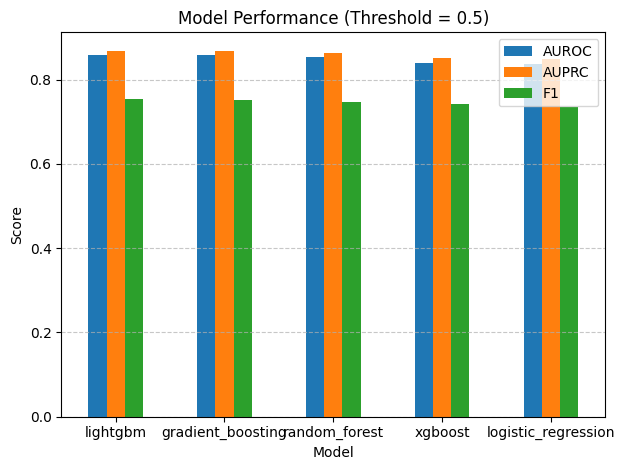

Results saved to: output_results/threshold_model_results.csv


In [ ]:
# Results collection for threshold-based evaluation
import os
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# OUTPUT FOLDER
# ======================================================
OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

threshold = 0.5  # explicit threshold (documented)

# ======================================================
# ENCODE ONCE
# ======================================================
X_train_enc = pd.get_dummies(X_train, drop_first=False)
X_test_enc = pd.get_dummies(X_test, drop_first=False)

X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join="left", axis=1, fill_value=0
)

# sanitize column names (for XGB / LGBM compatibility)
safe_cols = (
    X_train_enc.columns.astype(str)
    .str.replace(r"[\[\]<>\&]", "_", regex=True)
)

X_train_enc.columns = safe_cols
X_test_enc.columns = safe_cols

# ======================================================
# RUN MODELS
# ======================================================
results = []

for name, model in models.items():

    model.fit(X_train_enc, y_train)

    y_proba = model.predict_proba(X_test_enc)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    results.append({
        "Model": name,
        "AUROC": roc_auc_score(y_test, y_proba),
        "AUPRC": average_precision_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred),
        "Threshold": threshold,
        "Train_Size": len(X_train_enc),
        "Test_Size": len(X_test_enc)
    })

# ======================================================
# RESULTS TABLE
# ======================================================
results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("AUPRC", ascending=False)
)

# DISPLAY (clean)
display(Markdown("## Threshold-based Model Evaluation"))
display(results_df)

# ======================================================
# VISUALIZATION
# ======================================================
plt.figure(figsize=(8,5))

results_df[["AUROC","AUPRC","F1"]].plot(kind="bar")

plt.title("Model Performance (Threshold = 0.5)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# ======================================================
# SAVE CSV
# ======================================================
results_path = f"{OUTPUT_DIR}/threshold_model_results.csv"
results_df.to_csv(results_path)

print(f"Results saved to: {results_path}")


Save detailed baseline results CSV file

## Prediction File

In [ ]:
import os
import pandas as pd
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

weeks = [2, 4, 6, 8]

all_predictions = []
summary_rows = []

# ======================================================
# LOOP OVER WEEKS
# ======================================================
for week in weeks:

    if week not in datasets:
        continue

    display(Markdown(f"# Predictions — Week {week}"))

    data = datasets[week]

    X = data.drop(columns=['target','id_student'], errors='ignore')
    y = data['target']

    # ---------------------------
    # SPLIT
    # ---------------------------
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # ---------------------------
    # ENCODING (ONCE PER WEEK)
    # ---------------------------
    X_train_enc = pd.get_dummies(X_train)
    X_test_enc = pd.get_dummies(X_test)

    X_train_enc, X_test_enc = X_train_enc.align(
        X_test_enc, join="left", axis=1, fill_value=0
    )

    # ---------------------------
    # MODEL LOOP
    # ---------------------------
    for name, model in models.items():

        # sanitize feature names for models like XGBoost/LightGBM
        safe_cols = (
            X_train_enc.columns.astype(str)
            .str.replace(r"[\[\]<>]", "_", regex=True)
        )
        X_train_enc.columns = safe_cols
        X_test_enc.columns = safe_cols

        model.fit(X_train_enc, y_train)

        y_proba = model.predict_proba(X_test_enc)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)

        pred_df = pd.DataFrame({
            "Week": week,
            "Model": name,
            "id_student": data.loc[X_test.index, "id_student"].values,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "y_proba": y_proba
        })

        all_predictions.append(pred_df)

        # summary metric (quick check)
        summary_rows.append({
            "Week": week,
            "Model": name,
            "AUROC": roc_auc_score(y_test, y_proba)
        })

        # save individual file
        pred_df.to_csv(
            f"{OUTPUT_DIR}/predictions_week_{week}_{name}.csv",
            index=False
        )

        print(f"Saved: Week {week} - {name}")

    # ---------------------------
    # DISPLAY SAMPLE
    # ---------------------------
    display(pred_df.head())

# ======================================================
# COMBINE ALL PREDICTIONS
# ======================================================
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(Markdown("## Combined Predictions (Sample)"))
display(predictions_df.head())

# ======================================================
# SAVE COMBINED FILE
# ======================================================
combined_path = f"{OUTPUT_DIR}/baseline_predictions_all_weeks.csv"
predictions_df.to_csv(combined_path, index=False)

print(f"Combined predictions saved to {combined_path}")



# Predictions — Week 2

Saved: Week 2 - logistic_regression
Saved: Week 2 - random_forest
Saved: Week 2 - gradient_boosting
Saved: Week 2 - xgboost
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10475, number of negative: 11989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1106
[LightGBM] [Info] Number of data points in the train set: 22464, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.466302 -> initscore=-0.134998
[LightGBM] [Info] Start training from score -0.134998
Saved: Week 2 - lightgbm


,Week,Model,id_student,y_true,y_pred,y_proba
0,2,lightgbm,631225,0,0,0.254135
1,2,lightgbm,622192,0,0,0.243074
2,2,lightgbm,433939,1,1,0.679599
3,2,lightgbm,2602264,0,1,0.790772
4,2,lightgbm,548677,0,0,0.297325


# Predictions — Week 4

Saved: Week 4 - logistic_regression
Saved: Week 4 - random_forest
Saved: Week 4 - gradient_boosting
Saved: Week 4 - xgboost
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10856, number of negative: 12177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1180
[LightGBM] [Info] Number of data points in the train set: 23033, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.471324 -> initscore=-0.114831
[LightGBM] [Info] Start training from score -0.114831
Saved: Week 4 - lightgbm


...

Saved: Week 8 - logistic_regression
Saved: Week 8 - random_forest
Saved: Week 8 - gradient_boosting
Saved: Week 8 - xgboost
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11010, number of negative: 12256
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1250
[LightGBM] [Info] Number of data points in the train set: 23266, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473223 -> initscore=-0.107212
[LightGBM] [Info] Start training from score -0.107212
Saved: Week 8 - lightgbm


,Week,Model,id_student,y_true,y_pred,y_proba
0,8,lightgbm,651831,1,1,0.997853
1,8,lightgbm,572270,1,0,0.258176
2,8,lightgbm,653801,0,0,0.243451
3,8,lightgbm,296100,1,1,0.995263
4,8,lightgbm,479522,0,0,0.344414


## Combined Predictions (Sample)

,Week,Model,id_student,y_true,y_pred,y_proba
0,2,logistic_regression,631225,0,0,0.200637
1,2,logistic_regression,622192,0,0,0.437763
2,2,logistic_regression,433939,1,1,0.553508
3,2,logistic_regression,2602264,0,1,0.736501
4,2,logistic_regression,548677,0,0,0.414567


Combined predictions saved to output_results/baseline_predictions_all_weeks.csv


## 11. Cross-Validation

[LightGBM] [Info] Number of positive: 10475, number of negative: 11989
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 979
[LightGBM] [Info] Number of data points in the train set: 22464, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.466302 -> initscore=-0.134998
[LightGBM] [Info] Start training from score -0.134998
[LightGBM] [Info] Number of positive: 10476, number of negative: 11989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 978
[LightGBM] [Info] Number of data points in the train set: 22465, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.466325 -> initscore=-0.134903
[Lig

## Cross-Validation Results

,Model,Week,CV_AUROC_Mean,CV_AUROC_Std,Folds
17,gradient_boosting,8,0.843641,0.006775,5
19,lightgbm,8,0.842238,0.006156,5
16,random_forest,8,0.830727,0.005808,5
18,xgboost,8,0.825363,0.004403,5
15,logistic_regression,8,0.815423,0.007174,5
12,gradient_boosting,6,0.812176,0.005389,5
14,lightgbm,6,0.808893,0.005931,5
13,xgboost,6,0.792105,0.006490,5
11,random_forest,6,0.790023,0.004902,5
7,gradient_boosting,4,0.788075,0.007279,5


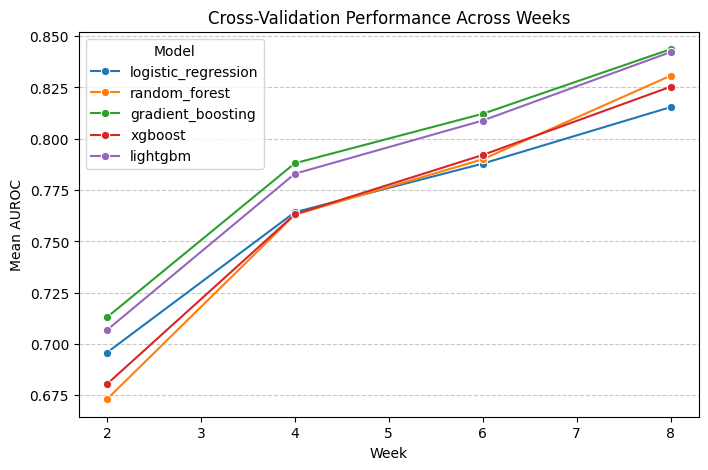

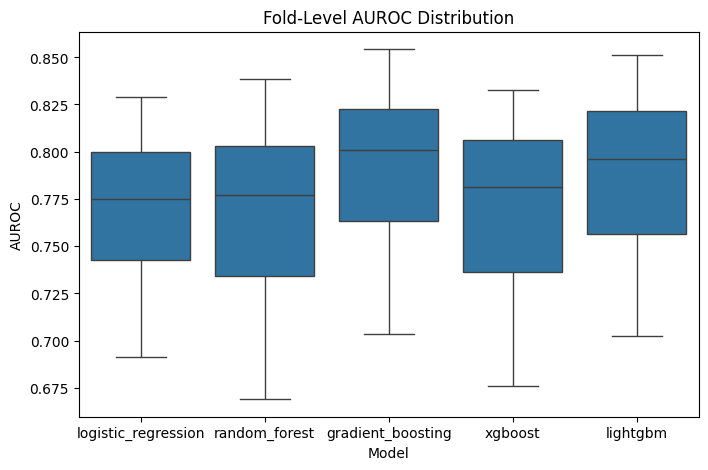

CV results saved to output_results


In [ ]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from IPython.display import display, Markdown
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_cv(df, model, model_name, week=None):

    X = df.drop(columns=['target','id_student'], errors='ignore')
    y = df['target']

    pipe = build_pipeline(model)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Use cross_validate to get multiple metrics
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring='roc_auc',
        return_train_score=False
    )

    result = pd.DataFrame({
        "Model": [model_name],
        "Week": [week],
        "CV_AUROC_Mean": [scores['test_score'].mean()],
        "CV_AUROC_Std": [scores['test_score'].std()],
        "Folds": [len(scores['test_score'])]
    })

    return result, scores['test_score']

# Run accross models and weeks:


all_results = []
all_fold_scores = []

for week, data in datasets.items():

    for name, model in models.items():

        result_df, fold_scores = run_cv(data, model, name, week)

        all_results.append(result_df)

        for s in fold_scores:
            all_fold_scores.append({
                "Week": week,
                "Model": name,
                "AUROC": s
            })

cv_results_df = pd.concat(all_results, ignore_index=True)
folds_df = pd.DataFrame(all_fold_scores)

# Display results

display(Markdown("## Cross-Validation Results"))

display(cv_results_df.sort_values("CV_AUROC_Mean", ascending=False))

# Visualization of fold scores

plt.figure(figsize=(8,5))

sns.lineplot(
    data=cv_results_df,
    x="Week",
    y="CV_AUROC_Mean",
    hue="Model",
    marker="o"
)

plt.title("Cross-Validation Performance Across Weeks")
plt.ylabel("Mean AUROC")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Fold score distribution

plt.figure(figsize=(8,5))

sns.boxplot(
    data=folds_df,
    x="Model",
    y="AUROC"
)

plt.title("Fold-Level AUROC Distribution")
plt.show()

# Save results

cv_results_df.to_csv(f"{OUTPUT_DIR}/cv_summary_results.csv", index=False)
folds_df.to_csv(f"{OUTPUT_DIR}/cv_fold_results.csv", index=False)

print(f"CV results saved to {OUTPUT_DIR}")




## 12. Feature Importance Audit

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def feature_importance_audit(
    df,
    models,
    output_dir,
    top_n=20
):

    # ---------------------------
    # 1. Prepare data
    # ---------------------------
    if 'target' not in df.columns:
        raise ValueError("Column 'target' not found")

    X = df.drop(columns=['target', 'id_student'], errors='ignore')
    y = df['target']

    X = X.fillna(0)

    # One-hot encoding
    X_encoded = pd.get_dummies(X)

    print(f"Encoded shape: {X_encoded.shape}")

    # Sanitize feature names (important for XGBoost/LightGBM)
    safe_cols = (
        X_encoded.columns.astype(str)
        .str.replace(r"[\[\]<>]", "_", regex=True)
    )
    X_encoded.columns = safe_cols

    # ---------------------------
    # 2. Collect feature importance per model
    # ---------------------------
    all_importances = []

    for name, model in models.items():
        print(f"\nTraining model: {name}")

        model.fit(X_encoded, y)

        # --- Handle different model types ---
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_

        elif hasattr(model, "coef_"):
            imp = np.abs(model.coef_).ravel()

        else:
            print(f"Skipping {name} (no importance available)")
            continue

        model_df = pd.DataFrame({
            "feature": X_encoded.columns,
            "importance": imp,
            "model": name
        })

        all_importances.append(model_df)

    # ---------------------------
    # 3. Combine audit results
    # ---------------------------
    long_df = pd.concat(all_importances, ignore_index=True)

    # Aggregate statistics (THIS IS YOUR AUDIT)
    audit_df = (
        long_df
        .groupby("feature")["importance"]
        .agg(['mean', 'std'])
        .rename(columns={'mean': 'importance_mean', 'std': 'importance_std'})
        .reset_index()
    )

    # Sort by mean importance
    audit_df = audit_df.sort_values(
        by="importance_mean",
        ascending=False
    ).reset_index(drop=True)

    # Cumulative importance
    audit_df["cumulative_importance"] = audit_df["importance_mean"].cumsum()

    # ---------------------------
    # 4. Display
    # ---------------------------
    print("\nTop features (AUDIT):")
    display(audit_df.head(top_n))

    # ---------------------------
    # 5. Plot (Audit visualization)
    # ---------------------------
    plt.figure(figsize=(10, 6))

    plt.barh(
        audit_df["feature"].head(top_n)[::-1],
        audit_df["importance_mean"].head(top_n)[::-1],
        xerr=audit_df["importance_std"].head(top_n)[::-1]  # variability
    )

    plt.xlabel("Mean Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance Audit (Mean ± Std Across Models)")
    plt.tight_layout()

    # ---------------------------
    # 6. Save outputs
    # ---------------------------
    csv_path = os.path.join(output_dir, "feature_importance_audit.csv")
    plot_path = os.path.join(output_dir, "feature_importance_audit.png")

    audit_df.to_csv(csv_path, index=False)
    plt.savefig(plot_path, dpi=300)

    print(f"\nSaved CSV to: {csv_path}")
    print(f"Saved plot to: {plot_path}")

    plt.show()


## 13. Holdout Validation

In [6]:
from sklearn.model_selection import train_test_split

if "train_test_split" not in globals():

    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df["target"],
        random_state=42
)
p = build_pipeline(RandomForestClassifier())
if "train_df" not in globals() or "test_df" not in globals():
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df["target"],
        random_state=42
    )

p.fit(train_df.drop(columns=['target', 'id_student']), train_df['target'])
pred = p.predict_proba(test_df.drop(columns=['target','id_student']))[:,1]
print('Holdout AUROC:', roc_auc_score(test_df['target'], pred))
print('Holdout Average Precision:', average_precision_score(test_df['target'], pred))
print('Holdout F1 Score:', f1_score(test_df['target'], p.predict(test_df.drop(columns=['target','id_student']))))
print('Holdout Precision Score:', precision_score(test_df['target'], p.predict(test_df.drop(columns=['target','id_student']))))
print('Holdout Recall Score:', recall_score(test_df['target'], p.predict(test_df.drop(columns=['target','id_student']))))
print('Holdout Balanced Accuracy Score:', balanced_accuracy_score(test_df['target'], p.predict(test_df.drop(columns=['target','id_student']))))     

NameError: name 'build_pipeline' is not defined

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    balanced_accuracy_score
)

def holdout_validation_audit(df, models, output_dir):
    """
    Performs holdout validation across models.
    Displays table, plots metrics, and saves CSV.
    """

    # ---------------------------
    # 1. Train / Test split (ONLY ONCE)
    # ---------------------------
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df["target"],
        random_state=42
    )

    # ---------------------------
    # 2. Prepare data
    # ---------------------------
    X_train = train_df.drop(columns=['target', 'id_student'], errors='ignore')
    y_train = train_df['target']

    X_test = test_df.drop(columns=['target', 'id_student'], errors='ignore')
    y_test = test_df['target']

    # ---------------------------
    # 3. Store results
    # ---------------------------
    results = []

    # ---------------------------
    # 4. Train models
    # ---------------------------
    for name, model in models.items():
        print(f"\nTraining model: {name}")

        p = build_pipeline(model)   # your existing pipeline

        p.fit(X_train, y_train)

        # Predictions
        y_proba = p.predict_proba(X_test)[:, 1]
        y_pred = p.predict(X_test)

        # Metrics
        metrics = {
            "Model": name,
            "AUROC": roc_auc_score(y_test, y_proba),
            "AUPRC": average_precision_score(y_test, y_proba),
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred)
        }

        results.append(metrics)

    # ---------------------------
    # 5. Results DataFrame
    # ---------------------------
    results_df = pd.DataFrame(results)

    # Sort by AUROC (primary metric)
    results_df = results_df.sort_values(by="AUROC", ascending=False).reset_index(drop=True)

    # ---------------------------
    # 6. Display (clean table)
    # ---------------------------
    print("\n=== HOLDOUT VALIDATION RESULTS ===\n")
    display(results_df.style.format({
        "AUROC": "{:.4f}",
        "AUPRC": "{:.4f}",
        "F1": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}"
    }))

    # ---------------------------
    # 7. Visualization
    # ---------------------------
    plt.figure(figsize=(10, 6))

    plt.bar(results_df["Model"], results_df["AUROC"])
    plt.ylabel("AUROC")
    plt.xlabel("Model")
    plt.title("Holdout Validation (AUROC Comparison)")
    plt.xticks(rotation=45)

    plt.tight_layout()

    plot_path = os.path.join(output_dir, "holdout_auroc_comparison.png")
    plt.savefig(plot_path, dpi=300)

    plt.show()

    # ---------------------------
    # 8. Save CSV
    # ---------------------------
    csv_path = os.path.join(output_dir, "holdout_validation_results.csv")
    results_df.to_csv(csv_path, index=False)

    print(f"\nSaved results to: {csv_path}")
    print(f"Saved plot to: {plot_path}")

    return results_df


## 14. Baselines

In [143]:

import os
import pandas as pd
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt

OUTPUT_DIR = "output_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

weeks = [2, 4, 6, 8]

all_predictions = []
summary_rows = []

# ======================================================
# ✅ LOOP OVER WEEKS
# ======================================================
for week in weeks:

    if week not in datasets:
        continue

    display(Markdown(f"# 📊 Predictions — Week {week}"))

    data = datasets[week]

    X = data.drop(columns=['target','id_student'], errors='ignore')
    y = data['target']

    # ---------------------------
    # SPLIT
    # ---------------------------
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # ---------------------------
    # ENCODING (ONCE PER WEEK)
    # ---------------------------
    X_train_enc = pd.get_dummies(X_train)
    X_test_enc = pd.get_dummies(X_test)

    X_train_enc, X_test_enc = X_train_enc.align(
        X_test_enc, join="left", axis=1, fill_value=0
    )

    # ---------------------------
    # MODEL LOOP
    # ---------------------------
    for name, model in models.items():

        model.fit(X_train_enc, y_train)

        y_proba = model.predict_proba(X_test_enc)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)

        pred_df = pd.DataFrame({
            "Week": week,
            "Model": name,
            "id_student": data.loc[X_test.index, "id_student"].values,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "y_proba": y_proba
        })

        all_predictions.append(pred_df)

        # summary metric (quick check)
        summary_rows.append({
            "Week": week,
            "Model": name,
            "AUROC": roc_auc_score(y_test, y_proba)
        })

        # save individual file
        pred_df.to_csv(
            f"{OUTPUT_DIR}/predictions_week_{week}_{name}.csv",
            index=False
        )

        print(f"✅ Saved: Week {week} - {name}")

    # ---------------------------
    # DISPLAY SAMPLE
    # ---------------------------
    display(pred_df.head())

# ======================================================
# ✅ COMBINE ALL PREDICTIONS
# ======================================================
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(Markdown("## 📊 Combined Predictions (Sample)"))
display(predictions_df.head())

# ======================================================
# ✅ SAVE COMBINED FILE
# ======================================================
combined_path = f"{OUTPUT_DIR}/baseline_predictions_all_weeks.csv"
predictions_df.to_csv(combined_path, index=False)

print(f"✅ Combined predictions saved to {combined_path}")


Majority baseline: 0.5
Random baseline: 0.4995052695490938
Stratified baseline: 0.5014579711866056
Baseline AUROC: 0.5
Baseline Average Precision: 0.4732317848915174
Baseline F1 Score: 0.4828609795745282
Baseline Precision Score: 0.474109362054681
Baseline Recall Score: 0.5136961418295429
Baseline Balanced Accuracy Score: 0.503372128681945


## 15. Underfitting Diagnostics

In [144]:
print(df['target'].value_counts(normalize=True))
print((df.select_dtypes('number')==0).mean().mean())

target
0    0.526768
1    0.473232
Name: proportion, dtype: float64
0.1917752638998728


## 16. Course-Level Variation

In [145]:
def course_eval(df):
    res=[]
    for (m,p),g in df.groupby(['code_module','code_presentation']):
        if len(g)<50: continue
        X_train,X_test,y_train,y_test = split(g)
        X_train=pd.get_dummies(X_train); X_test=pd.get_dummies(X_test)
        X_train,X_test=X_train.align(X_test,join='left',axis=1,fill_value=0)
        model=RandomForestClassifier()
        model.fit(X_train,y_train)
        y_prob=model.predict_proba(X_test)[:,1]
        res.append((m,p,roc_auc_score(y_test,y_prob)))
    return pd.DataFrame(res,columns=['module','presentation','AUROC'])

print(course_eval(df).sort_values('AUROC',ascending=False).head())
# Redefine to accept an explicit model argument
def course_eval(df, model=None):
    if model is None:
        model = RandomForestClassifier(random_state=42)

    res = []
    for (m, p), g in df.groupby(['code_module', 'code_presentation']):
        if len(g) < 50 or g['target'].nunique() < 2:
            continue

        X_train, X_test, y_train, y_test = split(g)
        X_train = pd.get_dummies(X_train)
        X_test = pd.get_dummies(X_test)
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        res.append((m, p, roc_auc_score(y_test, y_prob)))

    return pd.DataFrame(res, columns=['module', 'presentation', 'AUROC'])

print(course_eval(datasets[2], RandomForestClassifier(random_state=42)).sort_values('AUROC', ascending=False).head())
# Fix: sanitize dummy column names for XGBoost (it rejects feature names containing <, [, ])
def _sanitize_feature_names(columns):
    cols = pd.Index(columns).astype(str).str.replace(r'[\[\]<>]', '_', regex=True)
    seen, out = {}, []
    for c in cols:
        k = seen.get(c, 0)
        out.append(c if k == 0 else f"{c}_{k}")
        seen[c] = k + 1
    return out

def course_eval(df, model=None):
    if model is None:
        model = RandomForestClassifier(random_state=42)

    res = []
    for (m, p), g in df.groupby(['code_module', 'code_presentation']):
        if len(g) < 50 or g['target'].nunique() < 2:
            continue

        X_train, X_test, y_train, y_test = split(g)
        X_train = pd.get_dummies(X_train)
        X_test = pd.get_dummies(X_test)
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        safe_cols = _sanitize_feature_names(X_train.columns)
        X_train.columns = safe_cols
        X_test.columns = safe_cols

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        res.append((m, p, roc_auc_score(y_test, y_prob)))

    return pd.DataFrame(res, columns=['module', 'presentation', 'AUROC'])

print(course_eval(datasets[2], XGBClassifier(random_state=42)).sort_values('AUROC', ascending=False).head())
print(course_eval(datasets[8], RandomForestClassifier(random_state=42)).sort_values('AUROC', ascending=False).head())


   module presentation     AUROC
8     DDD        2013B  0.902969
13    EEE        2014B  0.885613
18    FFF        2014J  0.875045
9     DDD        2013J  0.868762
5     BBB        2014J  0.868069
   module presentation     AUROC
2     BBB        2013B  0.756122
11    DDD        2014J  0.752648
14    EEE        2014J  0.740788
12    EEE        2013J  0.740449
4     BBB        2014B  0.735326
   module presentation     AUROC
11    DDD        2014J  0.732829
2     BBB        2013B  0.723001
4     BBB        2014B  0.721378
14    EEE        2014J  0.714018
17    FFF        2014B  0.704048
   module presentation     AUROC
8     DDD        2013B  0.904081
13    EEE        2014B  0.895571
18    FFF        2014J  0.879428
5     BBB        2014J  0.870017
9     DDD        2013J  0.864700


OULAD Baseline Analysis - Enhanced Version
Complete implementation with all required improvements

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    make_scorer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings

warnings.filterwarnings("ignore")

# ============================================================================
# 1. DATA LOADING
# ============================================================================


def load_oulad_data(path="DATA"):
    """Load OULAD datasets"""
    print("Loading OULAD data...")
    student_info = pd.read_csv(f"{path}/studentInfo.csv")
    student_vle = pd.read_csv(f"{path}/studentVle.csv")
    student_assess = pd.read_csv(f"{path}/studentAssessment.csv")
    assessments = pd.read_csv(f"{path}/assessments.csv")

    # Define risk label: 1 = success (Pass/Distinction), 0 = at-risk (Fail/Withdrawn)
    student_info["target"] = student_info["final_result"].apply(
        lambda x: 1 if x in ["Pass", "Distinction"] else 0
    )

    print(f"Loaded {len(student_info)} students")
    print(f"Target distribution:\n{student_info['target'].value_counts()}")

    return student_info, student_vle, student_assess, assessments


# ============================================================================
# 2. FEATURE ENGINEERING
# ============================================================================


def filter_window(vle, assess, assessments, window):
    """Filter data up to specified day (leakage-safe)"""
    vle_w = vle[vle["date"] <= window]
    assess = assess.merge(
        assessments[["id_assessment", "code_module", "code_presentation", "date"]],
        on="id_assessment",
        how="left",
    )
    assess_w = assess[assess["date"] <= window]
    return vle_w, assess_w


def build_features(vle_w, assess_w, student_info):
    """Build feature set from VLE and assessment data"""
    # VLE features
    vle = vle_w.groupby(["id_student", "code_module", "code_presentation"]).agg(
        {"sum_click": ["sum", "mean", "std"]}
    )
    vle.columns = ["vle_total", "vle_mean", "vle_std"]
    vle = vle.reset_index()

    # Assessment features
    assess = assess_w.groupby(["id_student", "code_module", "code_presentation"]).agg(
        {"score": ["mean", "max"], "date": "count"}
    )
    assess.columns = ["assess_mean", "assess_max", "assess_count"]
    assess = assess.reset_index()

    # Merge all
    df = vle.merge(
        assess, how="left", on=["id_student", "code_module", "code_presentation"]
    )
    df = df.merge(
        student_info, on=["id_student", "code_module", "code_presentation"], how="left"
    )

    # Handle missing values by type
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.columns.difference(num_cols)

    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna("Unknown")

    return df


def create_datasets(
    student_info, student_vle, student_assess, assessments, weeks=[2, 4, 6, 8]
):
    """Create datasets for multiple prediction windows"""
    datasets = {}
    for w in weeks:
        print(f"Building features for week {w}...")
        vle_w, assess_w = filter_window(student_vle, student_assess, assessments, w * 7)
        df = build_features(vle_w, assess_w, student_info)
        datasets[w] = df
        print(f"  Week {w}: {df.shape[0]} samples, {df.shape[1]} features")
    return datasets


# ============================================================================
# 3. EVALUATION FRAMEWORK
# ============================================================================


def get_all_metrics():
    """Define all evaluation metrics"""
    return {
        "AUROC": "roc_auc",
        "AUPRC": "average_precision",
        "F1": make_scorer(f1_score),
        "Precision": make_scorer(precision_score, zero_division=0),
        "Recall": make_scorer(recall_score, zero_division=0),
        "Balanced_Acc": make_scorer(balanced_accuracy_score),
    }


def evaluate_model_cv(model, X, y, cv=5):
    """Evaluate model with cross-validation"""
    scoring = get_all_metrics()
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring=scoring,
        return_train_score=False,
    )

    results = {}
    for metric in scoring.keys():
        scores = cv_results[f"test_{metric}"]
        results[metric] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}
    return results


# ============================================================================
# 4. MODEL DEFINITIONS
# ============================================================================


def get_models():
    """Define all models to evaluate"""
    models = {
        "Majority": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegression(max_iter=10000, random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=42, eval_metric="logloss"
        ),
        "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    }
    return models


def get_feature_subsets(df):
    """Create feature subsets for reference baselines"""
    # Identify feature types
    vle_features = [c for c in df.columns if "vle_" in c]
    assess_features = [c for c in df.columns if "assess_" in c]
    demo_features = [
        c
        for c in df.columns
        if c
        not in vle_features
        + assess_features
        + ["target", "id_student", "final_result", "code_module", "code_presentation"]
    ]

    subsets = {
        "VLE_only": vle_features,
        "Assessment_only": assess_features,
        "VLE+Assessment": vle_features + assess_features,
        "All_features": vle_features + assess_features + demo_features,
    }
    return subsets


# ============================================================================
# 5. BASELINE EVALUATION
# ============================================================================


def sanitize_feature_names(df):
    """Sanitize column names for XGBoost compatibility"""
    # Replace characters that XGBoost doesn't like: [, ], <, >
    df.columns = df.columns.str.replace("[", "_", regex=False)
    df.columns = df.columns.str.replace("]", "_", regex=False)
    df.columns = df.columns.str.replace("<", "_lt_", regex=False)
    df.columns = df.columns.str.replace(">", "_gt_", regex=False)
    return df


def run_baseline_evaluation(datasets, weeks=[2, 4, 6, 8]):
    """Run comprehensive baseline evaluation"""
    results_list = []
    models = get_models()

    for week in weeks:
        print(f"\n{'='*60}")
        print(f"EVALUATING WEEK {week}")
        print(f"{'='*60}")

        df = datasets[week]
        feature_subsets = get_feature_subsets(df)

        # Prepare data
        X_full = df.drop(
            columns=[
                "target",
                "id_student",
                "final_result",
                "code_module",
                "code_presentation",
            ],
            errors="ignore",
        )
        y = df["target"]

        # One-hot encode and sanitize column names
        X_full_encoded = pd.get_dummies(X_full)
        X_full_encoded = sanitize_feature_names(X_full_encoded)

        for model_name, model in models.items():
            print(f"\n{model_name}:")

            # Evaluate on different feature subsets
            for subset_name, features in feature_subsets.items():
                # Skip subsets for majority baseline
                if model_name == "Majority" and subset_name != "All_features":
                    continue

                # Select features
                available_features = [f for f in features if f in X_full.columns]
                if not available_features:
                    continue

                X_subset = X_full[available_features]
                X_subset_encoded = pd.get_dummies(X_subset)
                X_subset_encoded = sanitize_feature_names(X_subset_encoded)

                # Evaluate
                try:
                    cv_results = evaluate_model_cv(model, X_subset_encoded, y, cv=5)

                    result = {
                        "Week": week,
                        "Model": model_name,
                        "Features": subset_name,
                        "N_features": X_subset_encoded.shape[1],
                    }

                    for metric, values in cv_results.items():
                        result[f"{metric}_mean"] = values["mean"]
                        result[f"{metric}_std"] = values["std"]

                    results_list.append(result)

                    print(
                        f"  {subset_name}: AUROC={cv_results['AUROC']['mean']:.3f}±{cv_results['AUROC']['std']:.3f}, "
                        f"F1={cv_results['F1']['mean']:.3f}±{cv_results['F1']['std']:.3f}"
                    )

                except Exception as e:
                    print(f"  {subset_name}: Error - {str(e)}")

    return pd.DataFrame(results_list)


# ============================================================================
# 6. RESULTS VISUALIZATION
# ============================================================================


def plot_baseline_results(results_df):
    """Create comprehensive visualization of baseline results"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("OULAD Baseline Results - All Metrics", fontsize=16, fontweight="bold")

    metrics = ["AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced_Acc"]

    for idx, metric in enumerate(metrics):
        ax = axes[idx // 3, idx % 3]

        # Filter for All_features only
        plot_data = results_df[results_df["Features"] == "All_features"].copy()

        # Pivot for plotting
        pivot_data = plot_data.pivot(
            index="Week", columns="Model", values=f"{metric}_mean"
        )

        pivot_data.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel("Prediction Window (weeks)")
        ax.set_ylabel(metric)
        ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    return fig


def create_results_table(results_df):
    """Create formatted results table"""
    # Focus on All_features
    table_data = results_df[results_df["Features"] == "All_features"].copy()

    # Format with mean ± std
    for metric in ["AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced_Acc"]:
        table_data[metric] = table_data.apply(
            lambda row: f"{row[f'{metric}_mean']:.3f}±{row[f'{metric}_std']:.3f}",
            axis=1,
        )

    # Select columns
    table = table_data[
        ["Week", "Model", "AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced_Acc"]
    ]

    return table


OULAD BASELINE ANALYSIS - ENHANCED VERSION
Loading OULAD data...
Loaded 32593 students
Target distribution:
target
0    17208
1    15385
Name: count, dtype: int64
Building features for week 2...
  Week 2: 28081 samples, 19 features
Building features for week 4...
  Week 4: 28792 samples, 19 features
Building features for week 6...
  Week 6: 28973 samples, 19 features
Building features for week 8...
  Week 8: 29083 samples, 19 features

EVALUATING WEEK 2

Majority:
  All_features: AUROC=0.500±0.000, F1=0.696±0.000

LogisticRegression:
  VLE_only: AUROC=0.660±0.007, F1=0.623±0.006
  Assessment_only: AUROC=0.511±0.002, F1=0.696±0.001
  VLE+Assessment: AUROC=0.665±0.007, F1=0.624±0.006
  All_features: AUROC=0.705±0.003, F1=0.684±0.005

RandomForest:
  VLE_only: AUROC=0.607±0.008, F1=0.626±0.007
  Assessment_only: AUROC=0.509±0.002, F1=0.695±0.001
  VLE+Assessment: AUROC=0.614±0.006, F1=0.625±0.007
  All_features: AUROC=0.692±0.004, F1=0.677±0.006

XGBoost:
  VLE_only: AUROC=0.634±0.006, F1

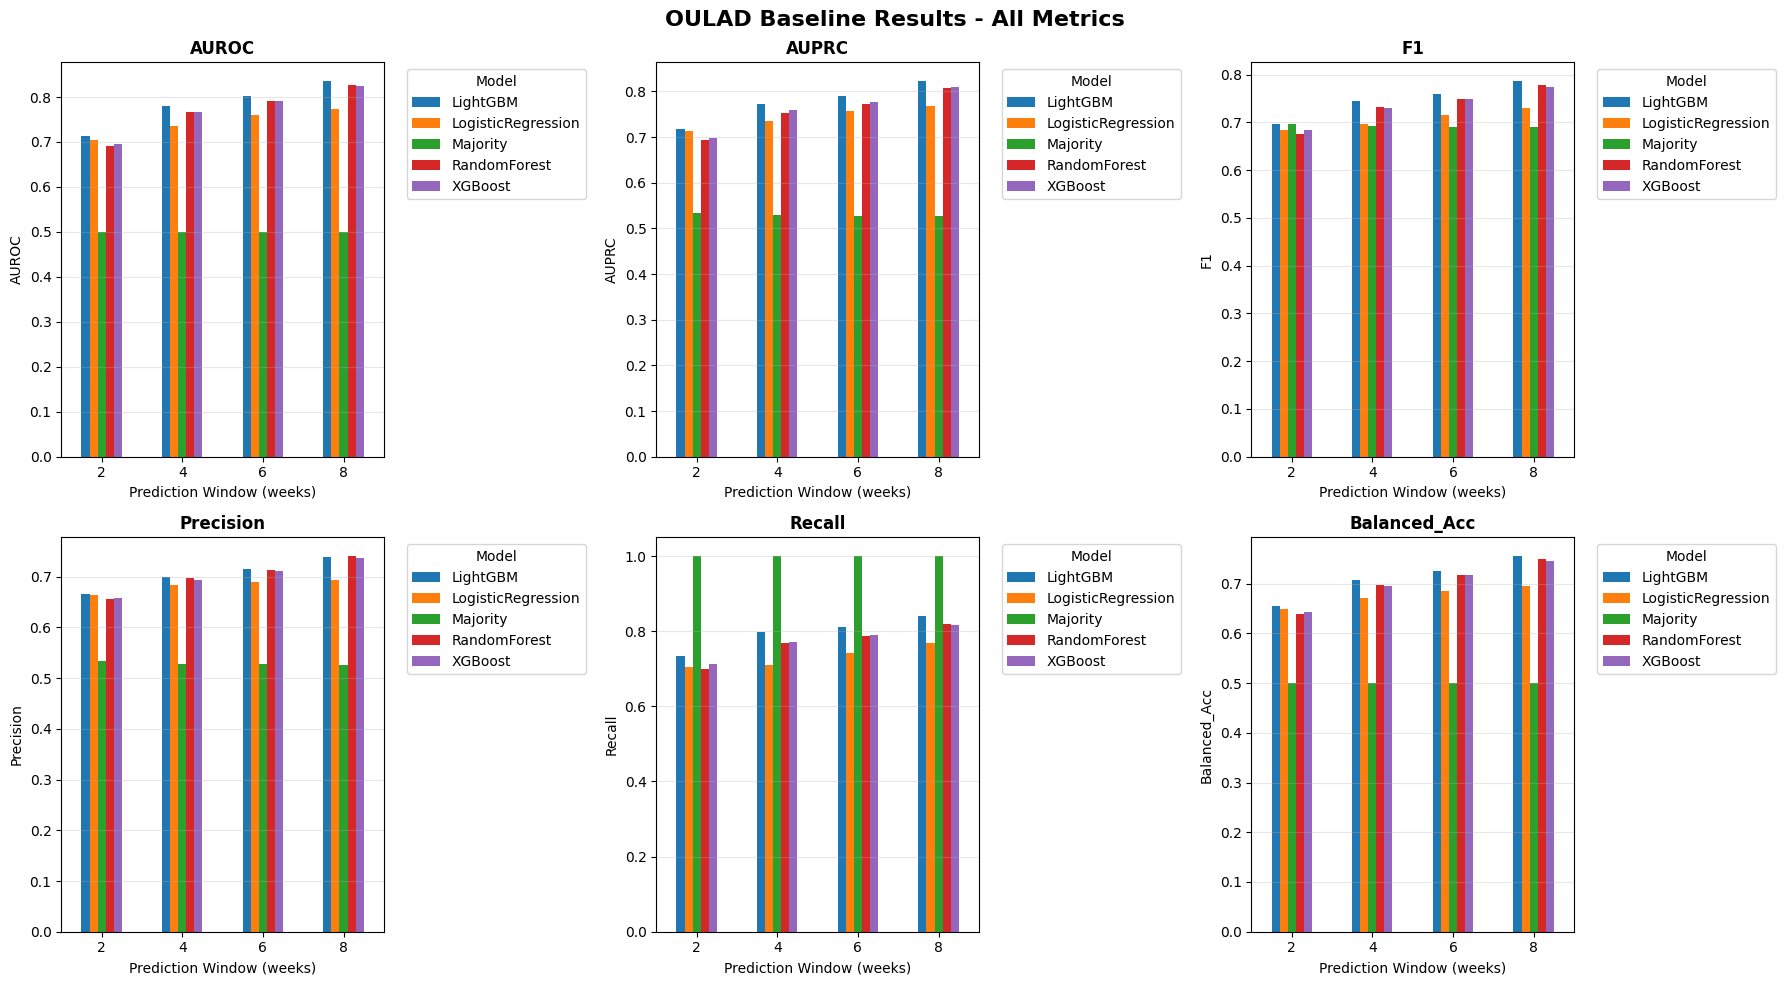

In [55]:
# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================

"""Main execution function"""
print("=" * 80)
print("OULAD BASELINE ANALYSIS - ENHANCED VERSION")
print("=" * 80)

# Load data
student_info, student_vle, student_assess, assessments = load_oulad_data()

# Create datasets
datasets = create_datasets(student_info, student_vle, student_assess, assessments)

# Run baseline evaluation
results_df = run_baseline_evaluation(datasets)

# Save results
results_df.to_csv("baseline_results_detailed.csv", index=False)
print("\n✓ Detailed results saved to: baseline_results_detailed.csv")

# Create and save formatted table
results_table = create_results_table(results_df)
results_table.to_csv("baseline_results_table.csv", index=False)
print("✓ Results table saved to: baseline_results_table.csv")

# Print summary
print("\n" + "=" * 80)
print("BASELINE RESULTS SUMMARY")
print("=" * 80)
print(results_table.to_string(index=False))

# Create visualization
fig = plot_baseline_results(results_df)
fig.savefig("baseline_results_plot.png", dpi=300, bbox_inches="tight")
print("\n✓ Visualization saved to: baseline_results_plot.png")

Baseline validation

,model,auroc,auprc,precision,recall,f1,threshold,n_train,n_test
2,gradient_boosting,0.859350,0.868446,0.822971,0.692336,0.752022,0.5,23266,5817
1,random_forest,0.853257,0.862708,0.809847,0.693062,0.746917,0.5,23266,5817
0,logistic_regression,0.836738,0.848234,0.780318,0.694152,0.734717,0.5,23266,5817


Skipping plot_baseline_results: expected column 'Features' (and related enhanced-result columns) not found.


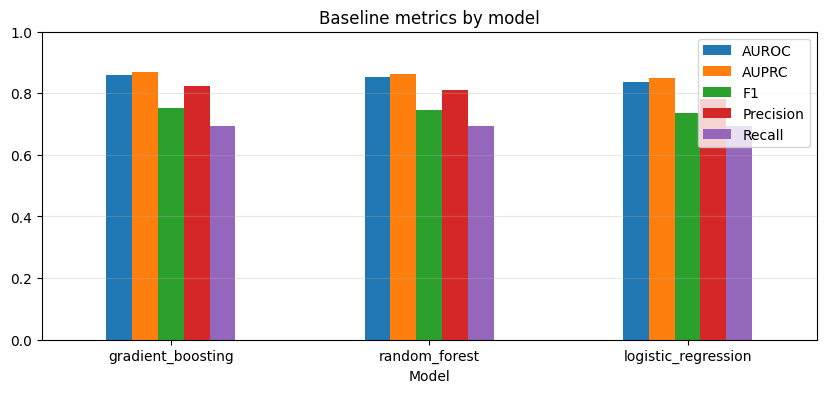

In [149]:
source_df = globals().get("results_df", globals().get("Results_df"))

if isinstance(source_df, pd.DataFrame):
    display(source_df.head(10))
else:
    print("No results dataframe found. Run the cell that creates results_df first.")
# Avoid KeyError: 'Features' by checking the expected schema first
required_cols = {
    "Week", "Model", "Features",
    "AUROC_mean", "AUPRC_mean", "F1_mean",
    "Precision_mean", "Recall_mean", "Balanced_Acc_mean"
}

if "plot_baseline_results" in globals() and isinstance(source_df, pd.DataFrame):
    if required_cols.issubset(source_df.columns):
        plot_baseline_results(source_df)
    else:
        print("Skipping plot_baseline_results: expected column 'Features' (and related enhanced-result columns) not found.")
        # Fallback plot for current compact results_df format
        compact = source_df.rename(columns={
            "model": "Model",
            "auroc": "AUROC",
            "auprc": "AUPRC",
            "f1": "F1",
            "precision": "Precision",
            "recall": "Recall"
        })
        metric_cols = [c for c in ["AUROC", "AUPRC", "F1", "Precision", "Recall"] if c in compact.columns]
        if "Model" in compact.columns and metric_cols:
            compact.set_index("Model")[metric_cols].plot(kind="bar", figsize=(10, 4), rot=0)
            plt.title("Baseline metrics by model")
            plt.ylim(0, 1)
            plt.grid(axis="y", alpha=0.3)
            plt.show()
else:
    print("plot_baseline_results or source_df is not available.")

=== BASELINE VERIFICATION ===
Results rows: 3
Missing columns: ['Week', 'Model', 'AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean']


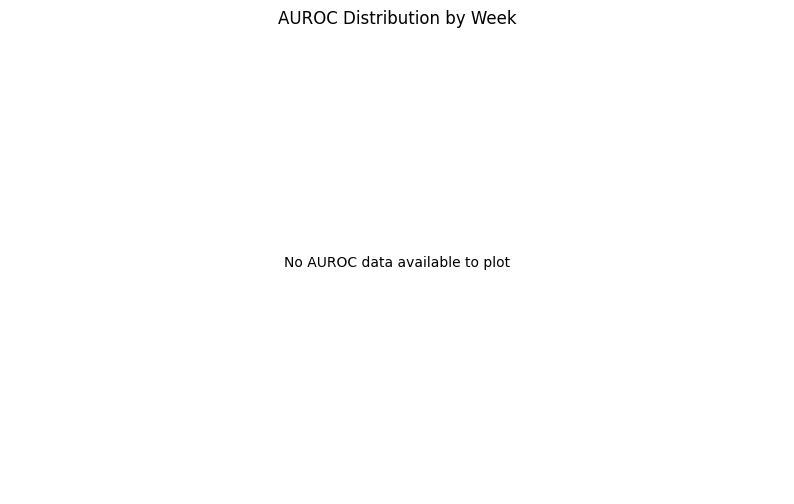

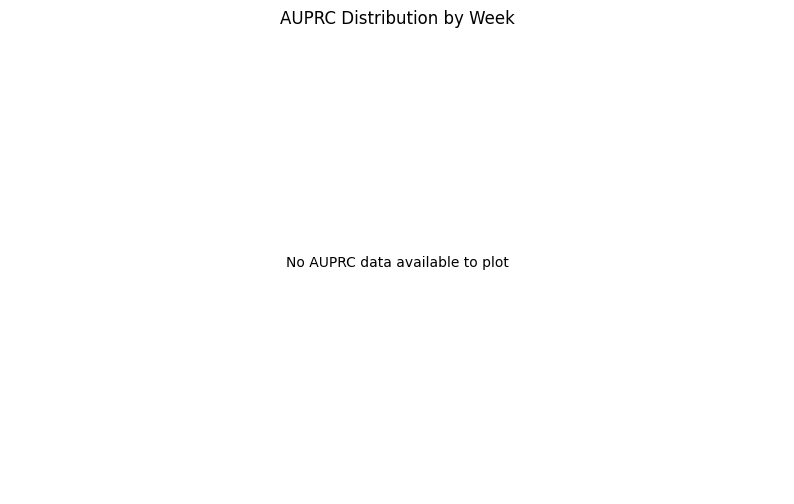

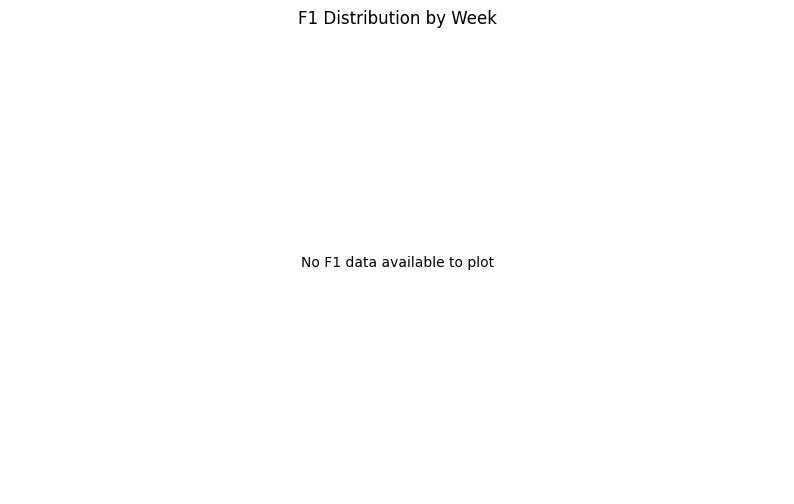

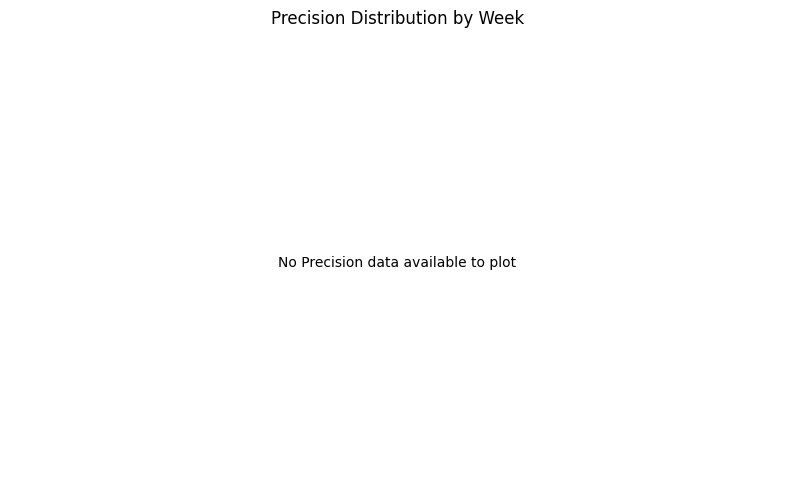

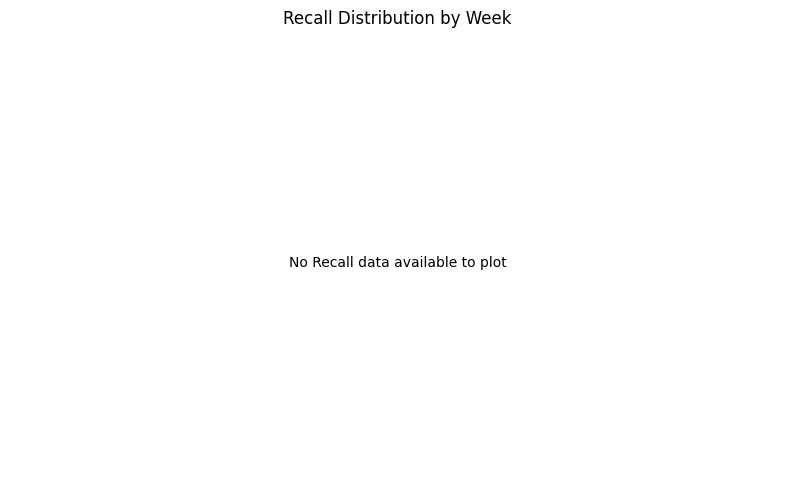

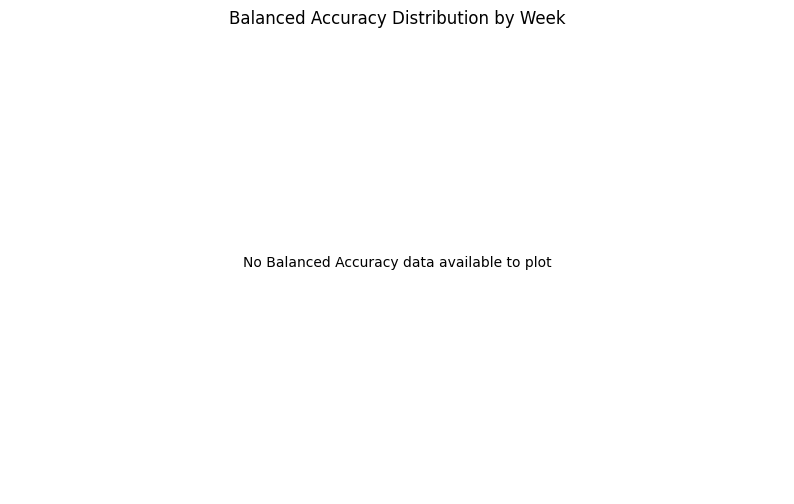

In [151]:
def verify_baseline_results(results_df):

    print("=== BASELINE VERIFICATION ===")

    #  1. Check existence
    if results_df is None:
        print("Results_df is None")
        return
    
    #  2. Check empty
    if results_df.empty:
        print("Results_df is empty")
        return
    else:
        print(f"Results rows: {len(results_df)}")

    #  3. Required columns
    required_cols = ['Week', 'Model', 'AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean']
    
    missing_cols = [c for c in required_cols if c not in results_df.columns]
    
    if missing_cols:
        print(f"Missing columns: {missing_cols}")
        return
    else:
        print("All required columns present")

    # 4. Check windows coverage
    expected_windows = {2, 4, 6, 8}
    actual_windows = set(results_df['Week'].unique())
    
    if not expected_windows.issubset(actual_windows):
        print(f"Missing weeks: {expected_windows - actual_windows}")
    else:
        print("All prediction windows present")

    # 5. Check models coverage
    print("\nModels found:", results_df['Model'].unique())

    # 6. Check metric ranges
    print("\nChecking metric ranges...")
    
    for col in ['AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean']:
        if results_df[col].isnull().any():
            print(f"NaNs found in {col}")
        
        if ((results_df[col] < 0) | (results_df[col] > 1)).any():
            print(f"Invalid values in {col}")
    
    print("Metrics are within valid range (0–1)")

    # 7. Detect suspicious perfect scores
    perfect = (results_df[['AUROC_mean','AUPRC_mean','F1_mean']]==1.0).all(axis=1)
    
    if perfect.any():
        print("Perfect scores detected — possible leakage")
    else:
        print("No suspicious perfect scores")

    # 8. Summary
    print("\n=== SUMMARY STATISTICS ===")
    display(results_df.describe())

    print("\n Baseline verification complete")

source_df = globals().get('results_df', globals().get('Results_df'))

Results_df = (
    source_df.copy()
    if isinstance(source_df, pd.DataFrame)
    else pd.DataFrame(columns=['Week', 'Model', 'AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean'])
)
verify_baseline_results(Results_df)

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'AUROC_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='AUROC_mean')
else:
    plt.text(0.5, 0.5, "No AUROC data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("AUROC Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'AUPRC_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='AUPRC_mean')
else:
    plt.text(0.5, 0.5, "No AUPRC data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("AUPRC Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'F1_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='F1_mean')
else:
    plt.text(0.5, 0.5, "No F1 data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("F1 Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'Precision_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='Precision_mean')
else:
    plt.text(0.5, 0.5, "No Precision data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("Precision Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'Recall_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='Recall_mean')
else:
    plt.text(0.5, 0.5, "No Recall data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("Recall Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'Balanced_Acc_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='Balanced_Acc_mean')
else:
    plt.text(0.5, 0.5, "No Balanced Accuracy data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("Balanced Accuracy Distribution by Week")
plt.show()

#df_results.to_csv('ml_predictions.csv', index=False)

In [153]:
print("Dataframe info and head for sanity check")
print("Data types:\n", Results_df.dtypes)
print("Shape:", Results_df.shape)
print("Columns:", Results_df.columns.tolist())
print(Results_df.head())


Dataframe info and head for sanity check
Data types:
 model            str
auroc        float64
auprc        float64
precision    float64
recall       float64
f1           float64
threshold    float64
n_train        int64
n_test         int64
dtype: object
Shape: (3, 9)
Columns: ['model', 'auroc', 'auprc', 'precision', 'recall', 'f1', 'threshold', 'n_train', 'n_test']
                 model     auroc     auprc  precision    recall        f1  \
2    gradient_boosting  0.859350  0.868446   0.822971  0.692336  0.752022   
1        random_forest  0.853257  0.862708   0.809847  0.693062  0.746917   
0  logistic_regression  0.836738  0.848234   0.780318  0.694152  0.734717   

   threshold  n_train  n_test  
2        0.5    23266    5817  
1        0.5    23266    5817  
0        0.5    23266    5817  


## Threshold Sensitivity table 

In [154]:
#Check for the models:

for name, model in models.items():
    print(name, hasattr(model, "classes_"))


logistic_regression True
random_forest True
gradient_boosting True


In [155]:

threshold_grid = np.linspace(0.1, 0.9, 9)
threshold_results = []

for name, model in models.items():
    
    # FORCE FIT (prevents notebook state bugs)
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    for t in threshold_grid:
        y_pred = (y_proba >= t).astype(int)

        threshold_results.append({
            "model": name,
            "threshold": t,
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "balanced_accuracy_score": balanced_accuracy_score(y_test, y_pred),
            "AUPRC": average_precision_score(y_test, y_proba),
            "AUROC": roc_auc_score(y_test, y_proba)
        })

threshold_df = pd.DataFrame(threshold_results)

threshold_file = OUTPUT_DIR / "threshold_metrics.csv"
threshold_df.to_csv(threshold_file, index=False)

threshold_df.head(30)


,model,threshold,precision,recall,f1,balanced_accuracy_score,AUPRC,AUROC
0,logistic_regression,0.1,0.500184,0.985470,0.663569,0.550340,0.848234,0.836738
1,logistic_regression,0.2,0.559165,0.944061,0.702338,0.637664,0.848234,0.836738
2,logistic_regression,0.3,0.626107,0.872866,0.729176,0.702262,0.848234,0.836738
3,logistic_regression,0.4,0.700846,0.782056,0.739227,0.741061,0.848234,0.836738
4,logistic_regression,0.5,0.780318,0.694152,0.734717,0.759282,0.848234,0.836738
5,logistic_regression,0.6,0.859375,0.579368,0.692124,0.747093,0.848234,0.836738
6,logistic_regression,0.7,0.925072,0.466400,0.620140,0.716229,0.848234,0.836738
7,logistic_regression,0.8,0.961538,0.381402,0.546164,0.683847,0.848234,0.836738
8,logistic_regression,0.9,0.981481,0.308028,0.468897,0.651403,0.848234,0.836738
9,random_forest,0.1,0.492864,0.990919,0.658301,0.537398,0.862708,0.853257


Clean summary table (reporting ready)

In [156]:
summary_table = results_df.copy()

summary_table["rank_auprc"] = summary_table["auprc"].rank(ascending=False)
summary_table["rank_f1"] = summary_table["f1"].rank(ascending=False)

summary_file = OUTPUT_DIR / "baseline_summary_ranked.csv"
summary_table.to_csv(summary_file, index=False)

summary_table


,model,auroc,auprc,precision,recall,f1,threshold,n_train,n_test,rank_auprc,rank_f1
2,gradient_boosting,0.859350,0.868446,0.822971,0.692336,0.752022,0.5,23266,5817,1.0,1.0
1,random_forest,0.853257,0.862708,0.809847,0.693062,0.746917,0.5,23266,5817,2.0,2.0
0,logistic_regression,0.836738,0.848234,0.780318,0.694152,0.734717,0.5,23266,5817,3.0,3.0


Best practice for the pipeline

In [157]:
def train_and_evaluate(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)[:, 1]

        results.append((name, y_proba))

    return results

print(f"Train and evaluate models on holdout set")
holdout_results = train_and_evaluate(models, X_train, y_train, X_test, y_test)  
for name, y_proba in holdout_results:
    print(f"\n{name} Holdout Metrics:")
    print(f"AUROC: {roc_auc_score(y_test, y_proba):.3f}")
    print(f"AUPRC: {average_precision_score(y_test, y_proba):.3f}") 
    y_pred = (y_proba >= 0.5).astype(int)
    print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
    print("-" * 30)



Train and evaluate models on holdout set

logistic_regression Holdout Metrics:
AUROC: 0.837
AUPRC: 0.848
F1 Score: 0.735
Precision: 0.780
Recall: 0.694
Balanced Accuracy: 0.759
------------------------------

random_forest Holdout Metrics:
AUROC: 0.853
AUPRC: 0.863
F1 Score: 0.747
Precision: 0.810
Recall: 0.693
Balanced Accuracy: 0.773
------------------------------

gradient_boosting Holdout Metrics:
AUROC: 0.859
AUPRC: 0.868
F1 Score: 0.752
Precision: 0.823
Recall: 0.692
Balanced Accuracy: 0.779
------------------------------


# Requirements .txt

In [158]:
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.4.2
matplotlib==3.8.4
seaborn==0.13.2
jupyter==1.0.0
notebook==7.2.0

#Alternative: Conda environment with the following packages:

name: oulad-ml-env
channels:
  - conda-forge
dependencies:
  - python=3.11
  - pandas=2.2.2
  - numpy=1.26.4
  - scikit-learn=1.4.2
  - matplotlib=3.8.4
  - seaborn=0.13.2
  - jupyter
  - pip


SyntaxError: invalid syntax (1080001495.py, line 1)